# Quantum-Computing Firms and Strategic Technology Incumbents: Financial, Return, Factor, Network, and Valuation Analysis

This notebook analyzes the **eight quantum-focused firms** in the revised case and adds three large strategic technology incumbents—IBM, Alphabet/Google, and Microsoft—that have invested in quantum computing while operating much larger, diversified businesses.

| Ticker | Company | Analytical treatment |
|---|---|---|
| ARQQ | Arqit Quantum Inc. | Quantum cybersecurity / quantum-safe cryptography |
| IONQ | IonQ Inc. | Trapped-ion quantum computing; quantum networking/sensing exposure |
| QBTS | D-Wave Quantum Inc. | Quantum annealing plus gate-model development |
| QNC | Quantum eMotion Corp. | Quantum cybersecurity / QRNG |
| QUBT | Quantum Computing Inc. | Integrated photonics / quantum optics |
| QUCY | Quantum Cyber N.V. | **2026 strategic/corporate transition**; historical data largely reflect predecessor Mainz Biomed |
| RGTI | Rigetti Computing Inc. | Superconducting quantum computing |
| XNDU | Xanadu Quantum Technologies Ltd. | Photonic quantum computing |
| IBM | International Business Machines Corp. | **Strategic incumbent** with substantial quantum R&D |
| GOOG | Alphabet Inc. (Google) | **Strategic incumbent** investing in frontier technologies including quantum computing |
| MSFT | Microsoft Corp. | **Strategic incumbent** investing in quantum hardware, software, cloud, and partnerships |

The revised notebook retains the original return, factor, accounting, WACC, and valuation analysis, but adds the strategic incumbents, separates them from startup valuation peers, restricts historical plots to **2020 onward**, expands financial-ratio visualization, documents the JKP/Ridge methodology, and deepens the network and DCF sections.

> **Important:** IBM, Alphabet, and Microsoft are not pure-play quantum-computing firms. Their consolidated accounting data measure the economics of the whole corporation, not a quantum segment. They are therefore strategic/financial benchmarks rather than direct startup peers. The term “loss leader” is used descriptively for their ability to fund long-horizon quantum R&D from profitable diversified businesses; the uploaded reports do not provide a standalone quantum profit-and-loss statement.


## Data-integrity and peer-comparability notes

1. **Historical window.** All historical stock and accounting time-series plots are restricted to **2020-01-01 onward**. Later-public firms begin at their economically relevant public-company start date.
2. **SPAC/predecessor histories.** ARQQ, IONQ, QBTS, and RGTI have pre-combination SPAC prices; QUBT has predecessor-company history. The return loader uses the later of 2020-01-01 and the designated economic-identity start date.
3. **QUCY structural break.** The 2025 filing is a Mainz Biomed filing. Pre-2026 accounting and return data do not describe the current quantum/cyber strategy, so QUCY remains excluded from the default startup valuation median.
4. **Strategic incumbents are a separate group.** IBM, Alphabet/Google, and Microsoft have quantum programs embedded in diversified corporations. Their consolidated ratios, betas, margins, R&D, cash flow, and valuation multiples are not quantum-segment metrics and are not included in the default quantum-startup valuation medians.
5. **GOOG share-count convention.** Alphabet's consolidated ordinary-share count is combined with the GOOG Class C price as an approximation to consolidated market capitalization. Alphabet has multiple share classes, so this is approximate.
6. **Cash-flow timing for incumbents.** The added quarterly CSVs extend through 2026, but the uploaded annual reports provide audited cash-flow statements through FY2025. The notebook uses FY2025 audited CFO/capex/FCF and labels that basis rather than fabricating 2026 cash flow.
7. **JKP factor coverage ends 2025-12-31.** QNC, XNDU, and post-transition QUCY have little or no overlap; the notebook reports insufficient coverage rather than backfilling predecessor returns.
8. **Early-stage accounting.** Negative earnings, tiny revenues, large equity issuance, warrants, acquisition accounting, and heavy R&D make conventional P/E, PEG, EV/EBITDA, and steady-state DCFs unstable for many observations.
9. **Interim statement convention.** Startup vendor financial CSVs are interim panels. TTM measures are approximated from those data; always inspect source filings before publication.


## 1. Imports and editable assumptions

In [1]:
# If your local environment is missing packages, uncomment and run once:
# %pip install pandas numpy scipy matplotlib statsmodels scikit-learn networkx openpyxl pypdf

from pathlib import Path
import csv, io, re, math, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# -----------------------------
# USER-ADJUSTABLE CASE SETTINGS
# -----------------------------
CORE_QUANTUM=['ARQQ','IONQ','QBTS','QNC','QUBT','QUCY','RGTI','XNDU']
STRATEGIC_INCUMBENTS=['IBM','GOOG','MSFT']
TICKERS=CORE_QUANTUM+STRATEGIC_INCUMBENTS
COMPANY_NAMES={
 'ARQQ':'Arqit Quantum Inc.','IONQ':'IonQ Inc.','QBTS':'D-Wave Quantum Inc.',
 'QNC':'Quantum eMotion Corp.','QUBT':'Quantum Computing Inc.','QUCY':'Quantum Cyber N.V.',
 'RGTI':'Rigetti Computing Inc.','XNDU':'Xanadu Quantum Technologies Ltd.',
 'IBM':'International Business Machines Corp.','GOOG':'Alphabet Inc. (Google)','MSFT':'Microsoft Corp.'}
PEER_GROUP={t:'Quantum-focused' for t in CORE_QUANTUM}; PEER_GROUP.update({t:'Strategic incumbent' for t in STRATEGIC_INCUMBENTS})
PLOT_START=pd.Timestamp('2020-01-01')
RETURN_START={'ARQQ':'2021-09-07','IONQ':'2021-10-01','QBTS':'2022-08-08','QNC':'2026-02-24','QUBT':'2018-07-20','QUCY':'2026-03-12','RGTI':'2022-03-02','XNDU':'2026-03-27','IBM':'2020-01-01','GOOG':'2020-01-01','MSFT':'2020-01-01'}
VALUATION_PEERS=['ARQQ','IONQ','QBTS','QNC','QUBT','RGTI','XNDU']
INCUMBENT_VALUATION_PEERS=STRATEGIC_INCUMBENTS.copy()
PERIODS_PER_TTM={t:4 for t in CORE_QUANTUM}; PERIODS_PER_TTM['ARQQ']=2
TRADING_DAYS=252
NETWORK_MIN_OVERLAP=60
NETWORK_ABS_CORR_THRESHOLD=.30
NETWORK_K_NEIGHBORS=2
NETWORK_NODE_SIZE_MODE='centrality' # 'centrality' or 'market_cap'
NETWORK_CENTRALITY_FOR_SIZE='Eigenvector Centrality'
NETWORK_GRAPH_TYPES=['threshold','mst','knn']
FORWARD_RF=.040; FORWARD_ERP=.050; TAX_RATE=.21; DEFAULT_PRETAX_COST_DEBT=.080
COST_DEBT_OVERRIDE={t:np.nan for t in TICKERS}
DCF_DEFAULTS={'forecast_years':10,'years_to_positive_fcf':5,'initial_revenue_growth':.35,'terminal_revenue_growth':.03,'target_fcf_margin':.20,'terminal_growth':.03,'wacc_floor':.06,'wacc_ceiling':.30}
INCUMBENT_DCF_DEFAULTS={'forecast_years':10,'years_to_positive_fcf':0,'initial_revenue_growth':.08,'terminal_revenue_growth':.03,'terminal_growth':.03}
JKP_MIN_OBS=120; JKP_TOP_N=12; JKP_LAG=1
JKP_IMPORTANCE_WEIGHTS={'Contemp corr':.25,'Contemp ridge coef':.25,'Lag corr':.25,'Lag ridge coef':.25}


## 2. Locate and extract the case archive

In [3]:
CASE_ZIP_NAME='Case 10.5 - Quantum Computing Cases.zip'
INCUMBENT_ZIP_NAME='Loss Leaders data.zip'
def locate_file(name):
    for p in [Path.cwd()/name,Path('/mnt/data')/name]:
        if p.exists(): return p
    raise FileNotFoundError(f'Place {name!r} beside this notebook or set its path manually.')
ZIP_PATH=locate_file(CASE_ZIP_NAME); INCUMBENT_ZIP_PATH=locate_file(INCUMBENT_ZIP_NAME)
EXTRACT_DIR=Path.cwd()/'quantum_case_data'; INCUMBENT_EXTRACT_DIR=Path.cwd()/'quantum_incumbent_data'
EXTRACT_DIR.mkdir(exist_ok=True); INCUMBENT_EXTRACT_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as zf:
    top=sorted({Path(n).parts[0] for n in zf.namelist() if n}); zf.extractall(EXTRACT_DIR)
with zipfile.ZipFile(INCUMBENT_ZIP_PATH) as zf:
    top_inc=sorted({Path(n).parts[0] for n in zf.namelist() if n}); zf.extractall(INCUMBENT_EXTRACT_DIR)
DATA_ROOT=EXTRACT_DIR/top[0]; INCUMBENT_ROOT=INCUMBENT_EXTRACT_DIR/top_inc[0]
PRICE_DIR=DATA_ROOT/'Stock Prices'; FIN_DIR=DATA_ROOT/'Financials'; REPORT_DIR=DATA_ROOT/'Annual Reports'
FF5_PATH=DATA_ROOT/'F-F_Research_Data_5_Factors_2x3_daily.csv'; JKP_PATH=DATA_ROOT/'[usa]_[all_factors]_[daily]_[vw].csv'
print('Quantum data:',DATA_ROOT); print('Strategic-incumbent data:',INCUMBENT_ROOT)


Quantum data: /mnt/data/quantum_case_data/Case 10.5 - Quantum Computing Cases
Strategic-incumbent data: /mnt/data/quantum_incumbent_data/Loss Leaders data


In [4]:
rows=[]
for root,label in [(DATA_ROOT,'Quantum case archive'),(INCUMBENT_ROOT,'Strategic-incumbent archive')]:
    for p in sorted(root.rglob('*')):
        if p.is_file(): rows.append({'source':label,'folder':str(p.parent.relative_to(root)),'file':p.name,'MB':p.stat().st_size/1e6})
inventory=pd.DataFrame(rows); display(inventory)


,source,folder,file,MB
0,Quantum case archive,Annual Reports,ARQQ_2025.pdf,6.3422
1,Quantum case archive,Annual Reports,IONQ_2025.pdf,0.8819
2,Quantum case archive,Annual Reports,QBTS_2025.pdf,3.3518
3,Quantum case archive,Annual Reports,QMCO_2025.pdf,33.5035
4,Quantum case archive,Annual Reports,QNC_2025_a.pdf,1.3276
5,Quantum case archive,Annual Reports,QNC_2025_b.pdf,0.5993
6,Quantum case archive,Annual Reports,QUBT_2025.pdf,3.9852
7,Quantum case archive,Annual Reports,QUCY_2025.pdf,3.2843
8,Quantum case archive,Annual Reports,RGTI_2025.pdf,1.7147
9,Quantum case archive,Annual Reports,XNDU_2025.pdf,2.8935


## 3. Load prices, define economically comparable return samples, and summarize coverage

In [5]:
def load_price_file(path):
    df=pd.read_csv(path); df['Date']=pd.to_datetime(df['Date']); df=df.sort_values('Date').drop_duplicates('Date')
    for c in ['Open','High','Low','Close','Adj Close','Volume']:
        if c in df: df[c]=pd.to_numeric(df[c],errors='coerce')
    df['Return']=df['Adj Close'].pct_change(); df['LogReturn']=np.log(df['Adj Close']).diff()
    return df.set_index('Date')
def price_path_for(t): return INCUMBENT_ROOT/f'{t}.csv' if t in STRATEGIC_INCUMBENTS else PRICE_DIR/f'{t}.csv'
prices_raw={}; prices={}
for t in TICKERS:
    p=price_path_for(t)
    if p.exists():
        prices_raw[t]=load_price_file(p); d=prices_raw[t].copy(); economic=pd.Timestamp(RETURN_START[t]) if RETURN_START.get(t) else PLOT_START
        prices[t]=d.loc[max(PLOT_START,economic):]
coverage=[]
for t in TICKERS:
    d0=prices_raw.get(t); d=prices.get(t)
    coverage.append({'Ticker':t,'Company':COMPANY_NAMES[t],'Peer group':PEER_GROUP[t],'Raw start':d0.index.min().date() if d0 is not None and len(d0) else None,'Analysis start':d.index.min().date() if d is not None and len(d) else None,'End':d.index.max().date() if d is not None and len(d) else None,'Obs':len(d) if d is not None else 0,'Latest Adj Close':d['Adj Close'].iloc[-1] if d is not None and len(d) else np.nan})
coverage=pd.DataFrame(coverage).set_index('Ticker'); display(coverage)


,Company,Peer group,Raw start,Analysis start,End,Obs,Latest Adj Close
Ticker,,,,,,,
ARQQ,Arqit Quantum Inc.,Quantum-focused,2021-04-01,2021-09-07,2026-09-17,1263,19.5200
IONQ,IonQ Inc.,Quantum-focused,2021-01-04,2021-10-01,2026-09-17,1245,40.7050
QBTS,D-Wave Quantum Inc.,Quantum-focused,2020-12-11,2022-08-08,2026-09-17,1032,17.8250
QNC,Quantum eMotion Corp.,Quantum-focused,2026-02-24,2026-02-24,2026-09-17,143,1.7050
QUBT,Quantum Computing Inc.,Quantum-focused,2007-02-01,2020-01-02,2026-09-17,1686,8.5000
QUCY,Quantum Cyber N.V.,Quantum-focused,2021-11-05,2026-03-12,2026-09-17,131,1.3700
RGTI,Rigetti Computing Inc.,Quantum-focused,2021-04-22,2022-03-02,2026-09-17,1141,16.1250
XNDU,Xanadu Quantum Technologies Ltd.,Quantum-focused,2026-03-23,2026-03-27,2026-09-17,120,7.6800
IBM,International Business Machines Corp.,Strategic incumbent,1962-01-02,2020-01-02,2026-09-17,1686,237.6600


## 4. Stock-return distributions and cumulative performance

In [6]:
def max_drawdown_from_returns(r):
    wealth=(1+r.dropna()).cumprod()
    dd=wealth/wealth.cummax()-1
    return dd.min() if len(dd) else np.nan

def return_stats(df):
    r=df['Return'].dropna()
    if len(r)<2:
        return pd.Series(dtype=float)
    arithmetic_daily=r.mean()
    arithmetic_ann=arithmetic_daily*TRADING_DAYS
    geo_ann=np.prod(1+r)**(TRADING_DAYS/len(r))-1
    vol_daily=r.std(ddof=1)
    vol_ann=vol_daily*np.sqrt(TRADING_DAYS)
    return pd.Series({
        'N':len(r),
        'Arithmetic Avg Daily':arithmetic_daily,
        'Arithmetic Avg Annualized':arithmetic_ann,
        'Geometric Avg Annualized':geo_ann,
        'Daily Std Dev':vol_daily,
        'Annualized Std Dev':vol_ann,
        'Skewness':stats.skew(r, bias=False, nan_policy='omit'),
        'Excess Kurtosis':stats.kurtosis(r, fisher=True, bias=False, nan_policy='omit'),
        'Min Daily Return':r.min(),
        'Max Daily Return':r.max(),
        'Max Drawdown':max_drawdown_from_returns(r),
    })

ret_stats=pd.DataFrame({t:return_stats(prices[t]) for t in prices}).T
ret_stats.index.name='Ticker'
display(ret_stats)

,N,Arithmetic Avg Daily,Arithmetic Avg Annualized,Geometric Avg Annualized,Daily Std Dev,Annualized Std Dev,Skewness,Excess Kurtosis,Min Daily Return,Max Daily Return,Max Drawdown
Ticker,,,,,,,,,,,
ARQQ,"1,263.0000",0.0016,0.4098,-0.3768,0.0854,1.3558,1.1719,6.5853,-0.4209,0.5693,-0.9960
IONQ,"1,245.0000",0.0031,0.7876,0.3181,0.0645,1.0234,0.7756,4.2462,-0.3900,0.3652,-0.9000
QBTS,"1,032.0000",0.0046,1.1641,0.1928,0.0933,1.4810,2.5606,21.9245,-0.3613,1.1074,-0.9667
QNC,142.0000,-0.0042,-1.0685,-0.7577,0.0528,0.8388,0.5728,0.4272,-0.1351,0.1549,-0.5442
QUBT,"1,686.0000",0.0042,1.0695,0.1684,0.0897,1.4238,2.5936,19.1833,-0.4334,0.9275,-0.9752
QUCY,131.0000,0.0231,5.8226,1.5392,0.3058,4.8541,8.8256,86.8972,-0.2364,3.1486,-0.7022
RGTI,"1,141.0000",0.0039,0.9870,0.1055,0.0858,1.3625,1.2298,6.7345,-0.4541,0.5805,-0.9602
XNDU,120.0000,0.0069,1.7464,-0.3902,0.1322,2.0979,1.0444,11.0364,-0.6127,0.6979,-0.7924
IBM,"1,686.0000",0.0007,0.1844,0.1433,0.0198,0.3144,-1.2490,23.5239,-0.2521,0.1296,-0.3898


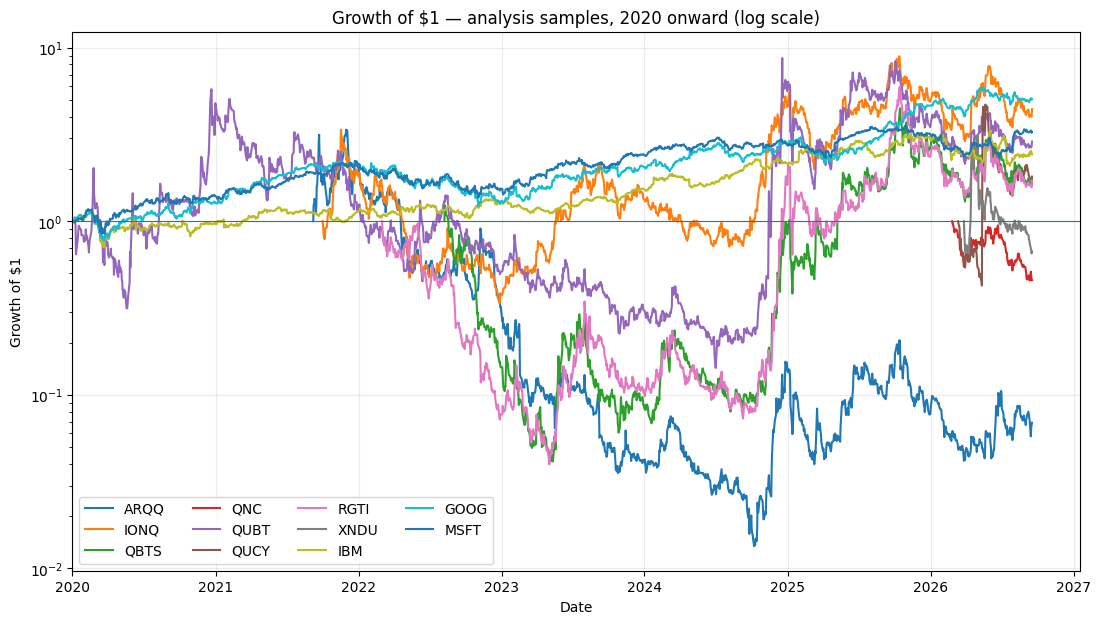

In [7]:
plt.figure(figsize=(13,7))
for t,d in prices.items():
    r=d.loc[PLOT_START:,'Return'].dropna()
    if len(r):
        cum=(1+r).cumprod(); cum=cum/cum.iloc[0]; plt.plot(cum.index,cum,label=t,linewidth=1.5)
plt.axhline(1,linewidth=.8); plt.yscale('log'); plt.xlim(left=PLOT_START); plt.title('Growth of $1 — analysis samples, 2020 onward (log scale)'); plt.ylabel('Growth of $1'); plt.xlabel('Date'); plt.legend(ncol=4); plt.grid(alpha=.25); plt.show()


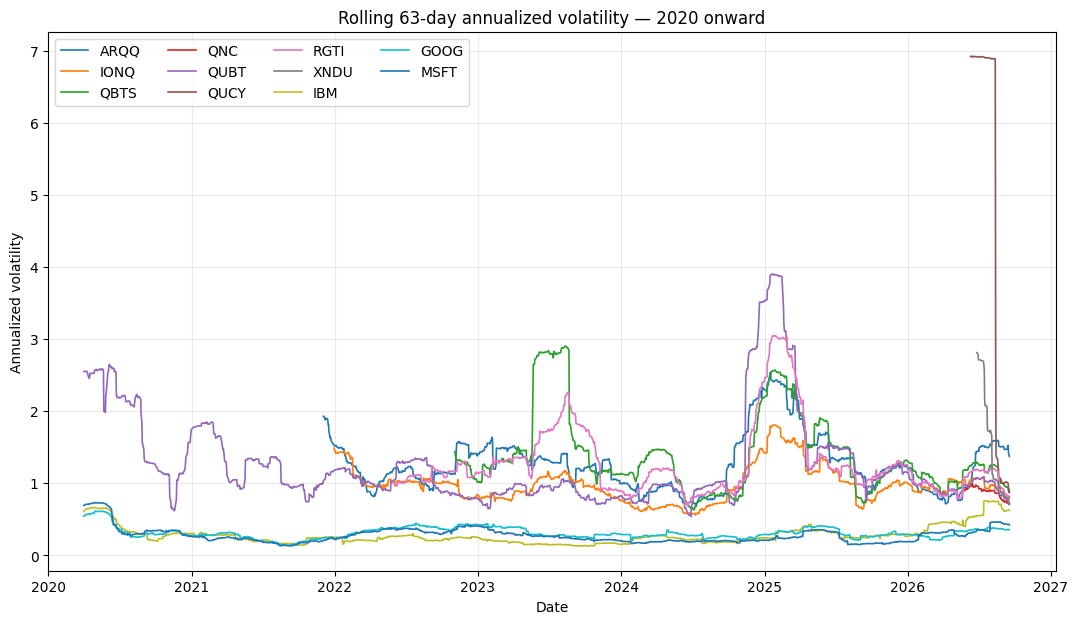

In [8]:
plt.figure(figsize=(13,7))
for t,d in prices.items():
    rv=d.loc[PLOT_START:,'Return'].rolling(63).std()*np.sqrt(TRADING_DAYS); plt.plot(rv.index,rv,label=t,linewidth=1.2)
plt.xlim(left=PLOT_START); plt.title('Rolling 63-day annualized volatility — 2020 onward'); plt.ylabel('Annualized volatility'); plt.xlabel('Date'); plt.legend(ncol=4); plt.grid(alpha=.25); plt.show()


## 5. Correlations and stock-return networks

The return network can be generated three ways: a **threshold graph** using absolute correlation, a **minimum spanning tree (MST)** using correlation distance $\sqrt{2(1-\rho)}$, or a **k-nearest-neighbor graph** using each stock's strongest absolute correlations. The notebook reports degree, weighted strength, betweenness, closeness, eigenvector centrality, and PageRank. Node size can be based on centrality or, after accounting data are loaded, market capitalization. Network centrality is descriptive of return co-movement, not evidence of technological leadership or causality.


,ARQQ,IONQ,QBTS,QNC,QUBT,QUCY,RGTI,XNDU,IBM,GOOG,MSFT
ARQQ,1.0000,0.3670,0.3986,0.2715,0.3736,0.0277,0.4629,0.3107,0.0851,0.1190,0.1469
IONQ,0.3670,1.0000,0.5195,0.5114,0.4809,0.0631,0.5939,0.4244,0.1595,0.3248,0.3448
QBTS,0.3986,0.5195,1.0000,0.5234,0.5241,0.0373,0.6284,0.4038,0.1073,0.1647,0.1861
QNC,0.2715,0.5114,0.5234,1.0000,0.4456,0.1158,0.5652,0.1949,-0.0189,0.2240,0.0963
QUBT,0.3736,0.4809,0.5241,0.4456,1.0000,0.0029,0.5177,0.3680,0.1098,0.1401,0.1419
QUCY,0.0277,0.0631,0.0373,0.1158,0.0029,1.0000,0.0459,0.0660,-0.0278,0.1719,0.0358
RGTI,0.4629,0.5939,0.6284,0.5652,0.5177,0.0459,1.0000,0.3345,0.1270,0.2332,0.2166
XNDU,0.3107,0.4244,0.4038,0.1949,0.3680,0.0660,0.3345,1.0000,0.0426,0.1790,0.2453
IBM,0.0851,0.1595,0.1073,-0.0189,0.1098,-0.0278,0.1270,0.0426,1.0000,0.2749,0.3383
GOOG,0.1190,0.3248,0.1647,0.2240,0.1401,0.1719,0.2332,0.1790,0.2749,1.0000,0.6301


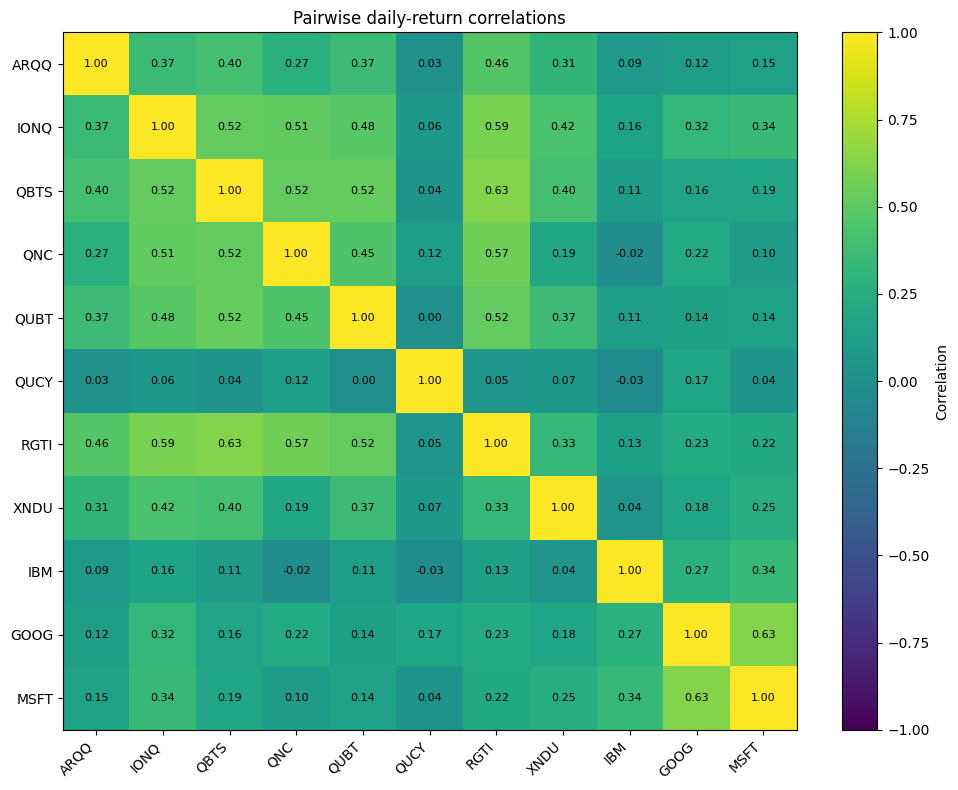

In [9]:
returns_wide=pd.concat({t:d['Return'] for t,d in prices.items()},axis=1)
returns_wide.columns=returns_wide.columns.get_level_values(0)
corr=returns_wide.corr(min_periods=NETWORK_MIN_OVERLAP)
display(corr)

fig,ax=plt.subplots(figsize=(10,8))
im=ax.imshow(corr.values,vmin=-1,vmax=1,aspect='auto')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns,rotation=45,ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        if pd.notna(corr.iloc[i,j]):
            ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='Correlation')
ax.set_title('Pairwise daily-return correlations')
plt.tight_layout(); plt.show()

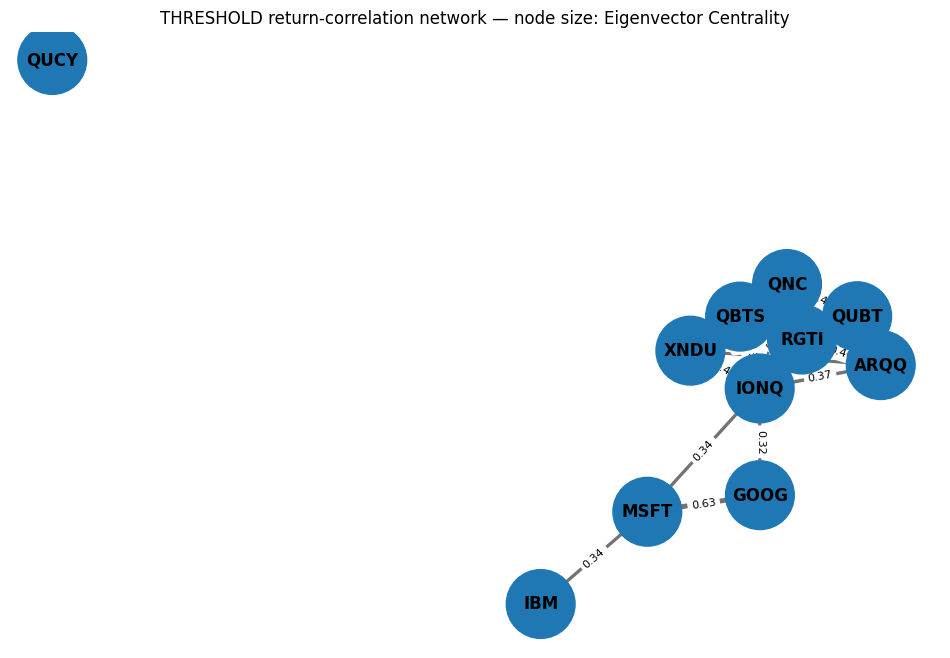


 THRESHOLD centrality


,Degree Centrality,Weighted Strength,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,PageRank
Ticker,,,,,,
ARQQ,0.5000,1.9128,0.0000,0.5226,NaN,0.0848
IONQ,0.8000,3.5665,0.4222,0.7578,NaN,0.1611
QBTS,0.6000,2.9978,0.0000,0.5988,NaN,0.1257
QNC,0.4000,2.0456,0.0000,0.5210,NaN,0.0892
QUBT,0.6000,2.7099,0.0000,0.5814,NaN,0.1149
QUCY,0.0000,0.0000,0.0000,0.0000,NaN,0.0148
RGTI,0.6000,3.1025,0.0222,0.6148,NaN,0.1298
XNDU,0.5000,1.8413,0.0000,0.5226,NaN,0.0823
IBM,0.1000,0.3383,0.0000,0.3200,NaN,0.0357


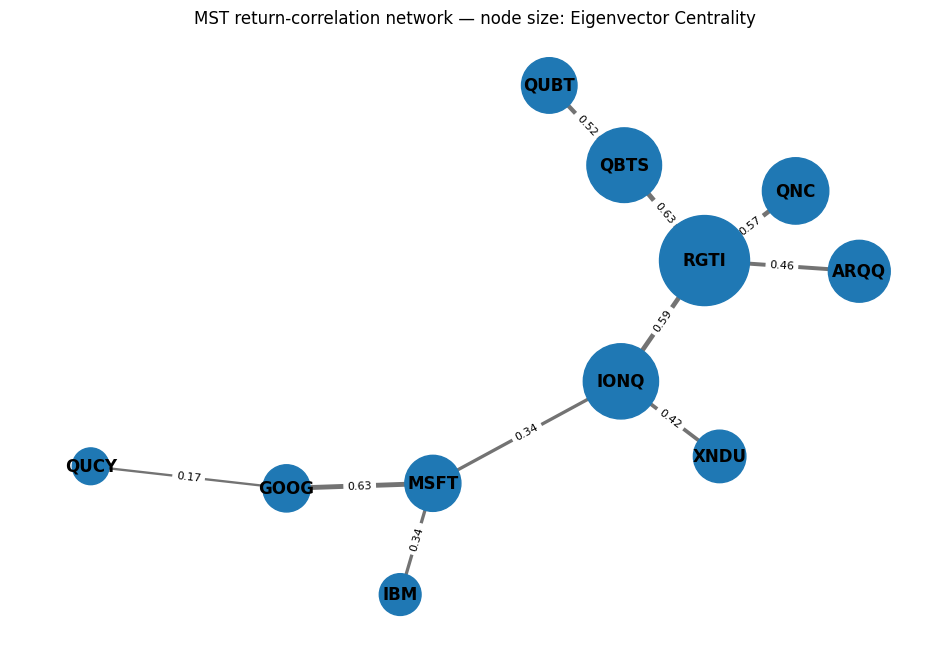


 MST centrality


,Degree Centrality,Weighted Strength,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,PageRank
Ticker,,,,,,
RGTI,0.4000,2.2503,0.6444,0.5029,0.6445,0.2066
IONQ,0.3000,1.3630,0.6444,0.5267,0.4157,0.1359
QBTS,0.2000,1.1526,0.2000,0.3858,0.4078,0.1106
QNC,0.1000,0.5652,0.0000,0.3536,0.2989,0.0577
ARQQ,0.1000,0.4629,0.0000,0.3423,0.2448,0.0498
MSFT,0.3000,1.3131,0.5111,0.4461,0.1809,0.1513
QUBT,0.1000,0.5241,0.0000,0.2882,0.1754,0.0564
XNDU,0.1000,0.4244,0.0000,0.3491,0.1448,0.0496
GOOG,0.2000,0.8020,0.2000,0.3516,0.0954,0.1029


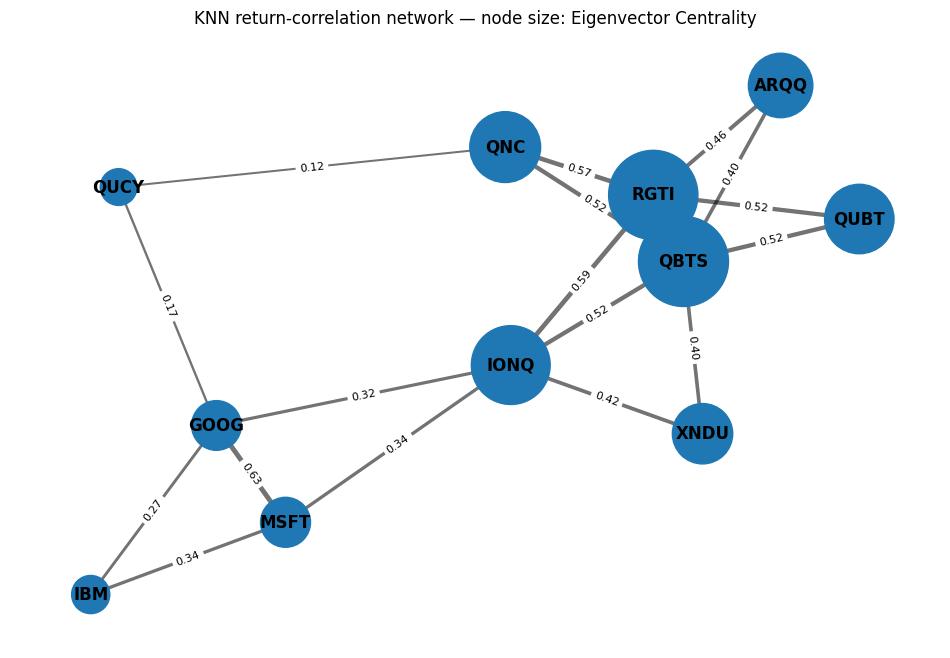


 KNN centrality


,Degree Centrality,Weighted Strength,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,PageRank
Ticker,,,,,,
QBTS,0.6000,2.9978,0.1111,0.6316,0.5303,0.1716
RGTI,0.5000,2.7680,0.3333,0.6159,0.5203,0.1581
IONQ,0.5000,2.2072,0.3556,0.6385,0.3899,0.1339
QNC,0.3000,1.2043,0.1111,0.4892,0.3012,0.0771
QUBT,0.2000,1.0418,0.0000,0.4285,0.2867,0.0643
ARQQ,0.2000,0.8615,0.0000,0.4173,0.2369,0.0555
XNDU,0.2000,0.8281,0.0000,0.4616,0.1989,0.0552
MSFT,0.3000,1.3131,0.1333,0.4812,0.1137,0.0961
GOOG,0.4000,1.4017,0.0889,0.5072,0.1116,0.1052


,Ticker 1,Ticker 2,Correlation,Overlap,Correlation distance
22,GOOG,MSFT,0.6301,1686,0.8601
14,QBTS,RGTI,0.6284,1032,0.8621
8,IONQ,RGTI,0.5939,1141,0.9013
17,QNC,RGTI,0.5652,142,0.9326
13,QBTS,QUBT,0.5241,1032,0.9756
12,QBTS,QNC,0.5234,142,0.9763
5,IONQ,QBTS,0.5195,1032,0.9804
18,QUBT,RGTI,0.5177,1141,0.9822
6,IONQ,QNC,0.5114,142,0.9885
7,IONQ,QUBT,0.4809,1245,1.0189


In [10]:
def build_return_network(corr_matrix,graph_type='threshold',threshold=NETWORK_ABS_CORR_THRESHOLD,k=NETWORK_K_NEIGHBORS):
    cols=list(corr_matrix.columns); base=nx.Graph(); base.add_nodes_from(cols); pairs=[]
    for i,a in enumerate(cols):
        for b in cols[i+1:]:
            c=corr_matrix.loc[a,b]; overlap=returns_wide[[a,b]].dropna().shape[0]
            if pd.notna(c) and overlap>=NETWORK_MIN_OVERLAP: pairs.append((a,b,float(c),overlap,float(np.sqrt(max(0,2*(1-c))))))
    if graph_type=='threshold':
        for a,b,c,o,d in pairs:
            if abs(c)>=threshold: base.add_edge(a,b,weight=abs(c),corr=c,overlap=o,distance=d)
    elif graph_type=='mst':
        full=nx.Graph(); full.add_nodes_from(cols)
        for a,b,c,o,d in pairs: full.add_edge(a,b,weight=abs(c),corr=c,overlap=o,distance=d)
        if full.number_of_edges(): base=nx.minimum_spanning_tree(full,weight='distance')
    elif graph_type=='knn':
        for a in cols:
            ranked=[]
            for x,y,c,o,d in pairs:
                if x==a: ranked.append((abs(c),y,c,o,d))
                elif y==a: ranked.append((abs(c),x,c,o,d))
            for _,b,c,o,d in sorted(ranked,reverse=True)[:k]: base.add_edge(a,b,weight=abs(c),corr=c,overlap=o,distance=d)
    else: raise ValueError('graph_type must be threshold, mst, or knn')
    return base

def network_centrality_table(G):
    degree=nx.degree_centrality(G); strength={n:sum(d.get('weight',1) for _,_,d in G.edges(n,data=True)) for n in G}
    between=nx.betweenness_centrality(G,weight='distance') if G.number_of_edges() else {n:0 for n in G}; close=nx.closeness_centrality(G,distance='distance') if G.number_of_edges() else {n:0 for n in G}
    try: eig=nx.eigenvector_centrality_numpy(G,weight='weight') if G.number_of_edges() else {n:0 for n in G}
    except Exception: eig={n:np.nan for n in G}
    pagerank=nx.pagerank(G,weight='weight') if G.number_of_edges() else {n:1/max(len(G),1) for n in G}
    out=pd.DataFrame({'Degree Centrality':pd.Series(degree),'Weighted Strength':pd.Series(strength),'Betweenness Centrality':pd.Series(between),'Closeness Centrality':pd.Series(close),'Eigenvector Centrality':pd.Series(eig),'PageRank':pd.Series(pagerank)}); out.index.name='Ticker'; return out.sort_values('Eigenvector Centrality',ascending=False)

def _scaled_node_sizes(values,min_size=700,max_size=4200):
    s=pd.Series(values,dtype=float).replace([np.inf,-np.inf],np.nan).fillna(0)
    if s.max()==s.min(): return {k:(min_size+max_size)/2 for k in s.index}
    z=(s-s.min())/(s.max()-s.min()); return {k:min_size+(max_size-min_size)*v for k,v in z.items()}

def plot_return_network(graph_type='threshold',node_size_mode='centrality',market_caps=None):
    G=build_return_network(corr,graph_type); cent=network_centrality_table(G)
    if node_size_mode=='market_cap' and market_caps is not None:
        vals=pd.Series({n:market_caps.get(n,np.nan) for n in G}); sizes=_scaled_node_sizes(vals); label='market capitalization'
    else:
        metric=NETWORK_CENTRALITY_FOR_SIZE; vals=cent[metric] if metric in cent else pd.Series(1,index=list(G)); sizes=_scaled_node_sizes(vals); label=metric
    plt.figure(figsize=(12,8)); pos=nx.spring_layout(G,seed=42,weight='weight'); nx.draw_networkx_nodes(G,pos,node_size=[sizes[n] for n in G]); nx.draw_networkx_labels(G,pos,font_weight='bold')
    pe=[(u,v) for u,v,d in G.edges(data=True) if d.get('corr',0)>=0]; ne=[(u,v) for u,v,d in G.edges(data=True) if d.get('corr',0)<0]
    if pe: nx.draw_networkx_edges(G,pos,edgelist=pe,width=[1+4*G[u][v]['weight'] for u,v in pe],alpha=.55)
    if ne: nx.draw_networkx_edges(G,pos,edgelist=ne,width=[1+4*G[u][v]['weight'] for u,v in ne],alpha=.55,style='dashed')
    nx.draw_networkx_edge_labels(G,pos,edge_labels={(u,v):f"{d['corr']:.2f}" for u,v,d in G.edges(data=True)},font_size=8); plt.title(f'{graph_type.upper()} return-correlation network — node size: {label}'); plt.axis('off'); plt.show(); return G,cent
RETURN_NETWORKS={}; RETURN_CENTRALITIES={}
for gt in NETWORK_GRAPH_TYPES:
    gg,cc=plot_return_network(gt,NETWORK_NODE_SIZE_MODE); RETURN_NETWORKS[gt]=gg; RETURN_CENTRALITIES[gt]=cc; print('\n',gt.upper(),'centrality'); display(cc)
G=RETURN_NETWORKS.get('threshold',build_return_network(corr,'threshold'))
network_edges=pd.DataFrame([{'Ticker 1':u,'Ticker 2':v,'Correlation':d['corr'],'Overlap':d['overlap'],'Correlation distance':d['distance']} for u,v,d in G.edges(data=True)])
if len(network_edges): network_edges=network_edges.sort_values('Correlation',key=lambda s:s.abs(),ascending=False)
display(network_edges)


## 6. Fama–French five-factor regressions

In [11]:
def load_ff5(path):
    # Kenneth French file: four descriptive rows, then header; factors are percentages.
    ff=pd.read_csv(path,skiprows=4)
    ff=ff.rename(columns={ff.columns[0]:'Date'})
    ff['Date']=pd.to_datetime(ff['Date'].astype(str),format='%Y%m%d',errors='coerce')
    ff=ff.dropna(subset=['Date']).set_index('Date')
    for c in ['Mkt-RF','SMB','HML','RMW','CMA','RF']:
        ff[c]=pd.to_numeric(ff[c],errors='coerce')/100.0
    return ff[['Mkt-RF','SMB','HML','RMW','CMA','RF']].dropna(how='all')

ff5=load_ff5(FF5_PATH)
print('FF5 coverage:',ff5.index.min().date(),'to',ff5.index.max().date(), 'N=',len(ff5))
display(ff5.tail())

FF5 coverage: 1963-07-01 to 2026-07-31 N= 15876


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2026-07-27,0.0015,0.0085,-0.0084,0.0038,0.0047,0.0002
2026-07-28,0.0027,0.0076,0.0045,0.0148,0.0053,0.0002
2026-07-29,-0.0152,0.0045,0.0031,0.0114,0.0089,0.0002
2026-07-30,0.0159,-0.0112,-0.0136,-0.0224,-0.0191,0.0002
2026-07-31,0.0068,-0.0038,-0.0059,0.0109,-0.0290,0.0002


In [12]:
def ff_regression(ticker, five_factor=True):
    r=prices[ticker]['Return'].rename('R')
    d=pd.concat([r,ff5],axis=1,join='inner').dropna()
    d['Excess']=d['R']-d['RF']
    factors=['Mkt-RF'] if not five_factor else ['Mkt-RF','SMB','HML','RMW','CMA']
    if len(d)<max(60,len(factors)+10):
        return None,None
    X=sm.add_constant(d[factors])
    m=sm.OLS(d['Excess'],X).fit(cov_type='HC1')
    return m,d

ff_rows=[]
ff_models={}
for t in prices:
    m,d=ff_regression(t,True)
    capm,_=ff_regression(t,False)
    if m is None: continue
    ff_models[t]=m
    row={
        'Ticker':t,'N':int(m.nobs),
        'Alpha daily':m.params.get('const',np.nan),
        'Alpha ann approx':m.params.get('const',np.nan)*TRADING_DAYS,
        'Alpha t':m.tvalues.get('const',np.nan),
        'MKT beta':m.params.get('Mkt-RF',np.nan),
        'SMB':m.params.get('SMB',np.nan),
        'HML':m.params.get('HML',np.nan),
        'RMW':m.params.get('RMW',np.nan),
        'CMA':m.params.get('CMA',np.nan),
        'Adj R2':m.rsquared_adj,
        'Residual Std Daily':np.std(m.resid,ddof=int(m.df_model)+1),
        'Residual Std Ann':np.std(m.resid,ddof=int(m.df_model)+1)*np.sqrt(TRADING_DAYS),
        'CAPM beta': capm.params.get('Mkt-RF',np.nan) if capm is not None else np.nan,
    }
    for fac in ['Mkt-RF','SMB','HML','RMW','CMA']:
        row[f'{fac} t']=m.tvalues.get(fac,np.nan)
    ff_rows.append(row)
ff_table=pd.DataFrame(ff_rows).set_index('Ticker')
display(ff_table)

,N,Alpha daily,Alpha ann approx,Alpha t,MKT beta,SMB,HML,RMW,CMA,Adj R2,Residual Std Daily,Residual Std Ann,CAPM beta,Mkt-RF t,SMB t,HML t,RMW t,CMA t
Ticker,,,,,,,,,,,,,,,,,,
ARQQ,1230,0.0015,0.3900,0.6563,0.8803,0.7389,-0.6949,-2.1950,0.3227,0.0827,0.0822,1.3051,1.6376,3.9914,1.7371,-1.8756,-5.1142,0.6650
IONQ,1212,0.0028,0.7152,1.8695,1.7979,0.7803,-0.7896,-2.4981,-0.3861,0.3366,0.0528,0.8382,2.8010,14.1043,3.3104,-2.9632,-9.7735,-1.1376
QBTS,999,0.0043,1.0796,1.5251,1.1590,1.2327,-0.5857,-3.5242,-0.1541,0.1333,0.0879,1.3946,2.3379,3.9854,2.3100,-1.2452,-6.8608,-0.2354
QNC,109,-0.0065,-1.6320,-1.5366,2.6589,-1.7742,-0.8549,-1.4618,1.6635,0.3407,0.0457,0.7247,3.2750,4.3877,-1.9200,-1.1275,-2.6636,1.7736
QUBT,1653,0.0038,0.9573,1.7815,1.1842,0.2360,0.0529,-2.3003,-0.0498,0.0740,0.0870,1.3813,1.4914,3.9493,0.6033,0.1638,-7.0091,-0.1174
QUCY,98,0.0363,9.1554,0.8603,3.8096,-3.3639,-8.6113,5.1922,-2.9994,0.0205,0.3485,5.5317,5.4299,1.7550,-0.6957,-1.3300,1.2896,-0.7543
RGTI,1108,0.0033,0.8414,1.4137,1.4713,1.4292,-0.4307,-3.0135,-0.3289,0.1809,0.0785,1.2458,2.5262,7.4221,3.4216,-1.1244,-7.3991,-0.6318
XNDU,87,0.0093,2.3369,0.5161,1.8906,0.9308,-4.0061,-1.8935,-0.7960,0.0955,0.1454,2.3076,5.2474,0.6989,0.4528,-1.3258,-1.3919,-0.4077
IBM,1653,0.0001,0.0237,0.2292,0.8326,0.0452,0.1918,0.1926,0.4640,0.3022,0.0165,0.2627,0.7464,22.0363,0.6434,3.4543,2.3357,4.9908


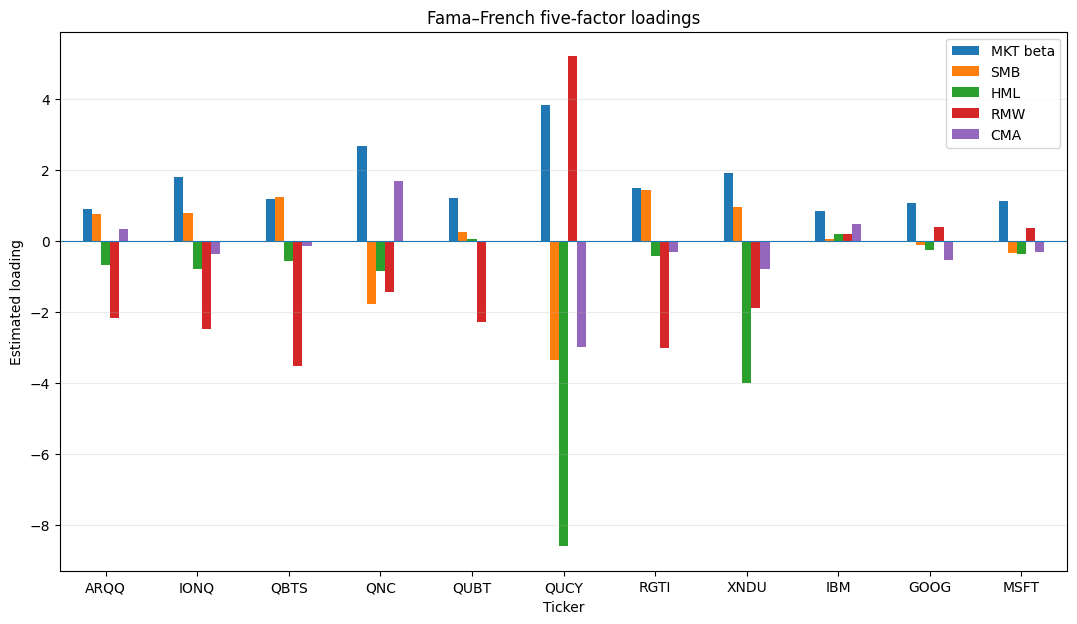

In [13]:
# Factor-loading plot
cols=['MKT beta','SMB','HML','RMW','CMA']
ff_table[cols].plot(kind='bar',figsize=(13,7))
plt.axhline(0,linewidth=.8)
plt.title('Fama–French five-factor loadings')
plt.ylabel('Estimated loading')
plt.xticks(rotation=0)
plt.grid(axis='y',alpha=.25)
plt.show()

### Reading the factor regressions

The five-factor regression is

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_{MKT}(R_{M,t}-R_{f,t})+\beta_{SMB}SMB_t+\beta_{HML}HML_t+\beta_{RMW}RMW_t+\beta_{CMA}CMA_t+\varepsilon_{i,t}.$$

For this peer set, the residual standard deviation is especially useful because firm-specific technology, financing, dilution, acquisition, and commercialization news can dominate systematic-factor exposure. The notebook therefore reports residual volatility alongside beta and $R^2$ rather than treating beta as a complete risk statistic.

## 7. Parse the vendor financial CSVs

In [14]:
SECTION_TITLES = {
    'Income Statement':'Income Statement - Interim',
    'Balance Sheet':'Balance Sheet - Interim',
    'Cash Flow':'Cash Flow - Interim',
    'Ratio Analysis':'Ratio Analysis - Interim',
}

def _clean_metric(x):
    return re.sub(r'\s+',' ',str(x)).strip()

def parse_vendor_financial(path):
    """Parse the multi-section vendor CSV into long tables.
    Financial-statement values are normalized to $000s when scale metadata permit.
    Ratio-analysis values are left in vendor units.
    """
    lines=Path(path).read_text(encoding='utf-8-sig',errors='replace').splitlines()
    out={}
    for sec,needle in SECTION_TITLES.items():
        title_idx=next((i for i,l in enumerate(lines) if needle in l),None)
        if title_idx is None: continue
        hdr_idx=title_idx+1
        header=next(csv.reader([lines[hdr_idx]]))
        dates=header[1:]
        rows=[]
        scale_row=None
        i=hdr_idx+1
        while i<len(lines):
            raw=lines[i]
            if raw.strip()=='' or any(n in raw for n in SECTION_TITLES.values()):
                break
            fields=next(csv.reader([raw]))
            metric=_clean_metric(fields[0] if fields else '')
            if metric=='Scale': scale_row=fields[1:]
            if metric and metric not in ['Currency','Scale']:
                vals=fields[1:]
                if len(vals)<len(dates): vals=vals+['']*(len(dates)-len(vals))
                for j,(ds,v) in enumerate(zip(dates,vals)):
                    dt=pd.to_datetime(ds,errors='coerce')
                    val=pd.to_numeric(v,errors='coerce')
                    if pd.isna(dt) or pd.isna(val): continue
                    sc=(scale_row[j] if scale_row and j<len(scale_row) else '')
                    rows.append({'metric':metric,'date':dt,'value':float(val),'scale':sc})
            i+=1
        df=pd.DataFrame(rows)
        if len(df):
            if sec!='Ratio Analysis':
                def to_k(row):
                    s=str(row['scale']).strip().lower()
                    if s.startswith('thousand'): return row['value']
                    if s.startswith('million'): return row['value']*1000
                    if s in ('','na','nan'): return row['value']*1000  # vendor uses millions when scale is NA in several legacy/foreign-filer columns
                    return row['value']/1000
                df['value_k']=df.apply(to_k,axis=1)
            # Duplicate vendor dates occasionally exist; keep first non-missing observation.
            df=df.sort_values(['metric','date']).drop_duplicates(['metric','date'],keep='first')
        out[sec]=df
    return out

financials={}
for t in TICKERS:
    p=FIN_DIR/f'{t}.csv'
    if p.exists(): financials[t]=parse_vendor_financial(p)

print('Parsed financial panels:',sorted(financials))

Parsed financial panels: ['ARQQ', 'IONQ', 'QBTS', 'QNC', 'QUBT', 'QUCY', 'RGTI']


In [15]:
# Quick metric lookup utilities

def metric_series(ticker, section, metric, normalized_k=True):
    if ticker not in financials or section not in financials[ticker]:
        return pd.Series(dtype=float)
    d=financials[ticker][section]
    d=d[d['metric'].str.lower()==metric.lower()].sort_values('date')
    col='value_k' if normalized_k and section!='Ratio Analysis' and 'value_k' in d else 'value'
    return d.set_index('date')[col]

def find_metric(ticker, section, patterns):
    if ticker not in financials or section not in financials[ticker]: return []
    mets=financials[ticker][section]['metric'].drop_duplicates().tolist()
    if isinstance(patterns,str): patterns=[patterns]
    return [m for m in mets if all(p.lower() in m.lower() for p in patterns)]

def latest_metric(ticker,section,metric,normalized_k=True):
    s=metric_series(ticker,section,metric,normalized_k)
    return s.dropna().iloc[-1] if len(s.dropna()) else np.nan

def ttm_sum(ticker,metric,n_periods=None):
    s=metric_series(ticker,'Income Statement',metric,True).dropna().sort_index()
    n=n_periods or PERIODS_PER_TTM.get(ticker,4)
    return s.tail(n).sum() if len(s) else np.nan

def prior_ttm_sum(ticker,metric,n_periods=None):
    s=metric_series(ticker,'Income Statement',metric,True).dropna().sort_index()
    n=n_periods or PERIODS_PER_TTM.get(ticker,4)
    return s.iloc[-2*n:-n].sum() if len(s)>=2*n else np.nan

def ratio_latest(ticker,metric):
    s=metric_series(ticker,'Ratio Analysis',metric,False).dropna().sort_index()
    return s.iloc[-1] if len(s) else np.nan

# Show the available ratio names for one representative firm.
if 'IONQ' in financials:
    display(pd.DataFrame({'IONQ ratio metrics': financials['IONQ']['Ratio Analysis']['metric'].drop_duplicates().tolist()}))

,IONQ ratio metrics
0,Asset Turnover TTM
1,Book Value Per Share
2,Cash Cycle (DOH+DSO-DP)
3,Current Ratio
4,Days Inventory (DOH)
5,Days Payable (DP)
6,Days Receivable (DSO)
7,EBITDA Margin %
8,Effective Tax Rate
9,Financial Leverage Ratio


### Strategic-incumbent accounting data

IBM, GOOG, and MSFT use a wide quarterly format. Values are normalized to **$000s** (and share counts to thousands of shares). The uploaded annual reports supply audited FY2025 cash-flow figures; simple FCF is CFO minus capital expenditures. For IBM, capitalized software investment is included with capex because it is an economically similar long-lived investment.


In [16]:
def _parse_numeric_string(x):
    if pd.isna(x): return np.nan
    s=str(x).replace(',','').replace('$','').strip(); neg=s.startswith('(') and s.endswith(')'); s=s.strip('()'); v=pd.to_numeric(s,errors='coerce')
    return (-float(v) if neg else float(v)) if pd.notna(v) else np.nan

def parse_incumbent_wide_statement(path):
    raw=pd.read_csv(path,dtype=str); raw['metric']=raw['name'].astype(str).str.replace(r'\s+',' ',regex=True).str.strip(); dates=[c for c in raw.columns if c not in ['name','metric','ttm'] and pd.notna(pd.to_datetime(c,errors='coerce'))]; rows=[]
    for _,r in raw.iterrows():
        for c in dates:
            v=_parse_numeric_string(r[c])
            if pd.notna(v): rows.append({'metric':r['metric'],'date':pd.to_datetime(c),'value_k':v/1000})
    ttm={}
    if 'ttm' in raw:
        for _,r in raw.iterrows():
            v=_parse_numeric_string(r['ttm'])
            if pd.notna(v): ttm[r['metric']]=v/1000
    return {'long':pd.DataFrame(rows),'ttm_k':pd.Series(ttm,dtype=float)}
incumbent_financials={t:{'Balance Sheet':parse_incumbent_wide_statement(INCUMBENT_ROOT/f'{t}_quarterly_balance-sheet.csv'),'Income Statement':parse_incumbent_wide_statement(INCUMBENT_ROOT/f'{t}_quarterly_financials.csv')} for t in STRATEGIC_INCUMBENTS}
def inc_metric_series(t,section,metric):
    d=incumbent_financials[t][section]['long']; z=d[d.metric.str.lower()==metric.lower()].sort_values('date'); return z.set_index('date')['value_k']
def inc_latest(t,section,metric):
    s=inc_metric_series(t,section,metric).dropna(); return s.iloc[-1] if len(s) else np.nan
def inc_ttm(t,metric):
    s=incumbent_financials[t]['Income Statement']['ttm_k']; match=[m for m in s.index if m.lower()==metric.lower()]
    if match: return float(s.loc[match[0]])
    q=inc_metric_series(t,'Income Statement',metric).dropna().sort_index(); return q.tail(4).sum() if len(q) else np.nan
def inc_prior_ttm(t,metric):
    q=inc_metric_series(t,'Income Statement',metric).dropna().sort_index(); return q.iloc[-8:-4].sum() if len(q)>=8 else np.nan
INCUMBENT_CASHFLOW_ANNUAL={
 'GOOG':pd.DataFrame({'CFO $000':[101746000,125299000,164713000],'Capex $000':[32251000,52535000,91447000]},index=[2023,2024,2025]),
 'MSFT':pd.DataFrame({'CFO $000':[87582000,118548000,136162000],'Capex $000':[28107000,44477000,64551000]},index=[2023,2024,2025]),
 'IBM':pd.DataFrame({'CFO $000':[13931000,13445000,13193000],'Capex $000':[1810000,1685000,1738000]},index=[2023,2024,2025])}
for t,df in INCUMBENT_CASHFLOW_ANNUAL.items(): df['FCF $000']=df['CFO $000']-df['Capex $000']; df.index.name='Year'
print('Strategic-incumbent panels:',sorted(incumbent_financials))


Strategic-incumbent panels: ['GOOG', 'IBM', 'MSFT']


## 8. XNDU annual-report financial supplement

**XNDU valuation caveat:** the income statement and balance sheet below are pre-business-combination 2025 figures, while market-value calculations use the post-combination share count reported as of April 2, 2026. The March 2026 transaction raised substantial new capital, so EV and cash-runway measures that rely on the 2025 cash balance are conservative/stale unless the user supplies a post-close cash override from a later filing.

In [17]:
# XNDU has no vendor Financials/XNDU.csv in the archive. The following audited 2023-2025
# values are transcribed from XNDU_2025.pdf, pages F-14, F-15, and F-17 (amounts in $000s).
# This preserves XNDU in accounting comparisons without pretending that a missing vendor file exists.

XNDU_ANNUAL = pd.DataFrame({
    2023:{
        'Revenue':2479,'Cost of Revenue':605,'R&D':35718,'G&A':6034,'Sales & Marketing':607,
        'D&A':3730,'Operating Income':-41697,'Net Income':-35592,'CFO':-29549,'Capex':-8899,
        'Cash':117459,
    },
    2024:{
        'Revenue':1589,'Cost of Revenue':466,'R&D':39223,'G&A':6863,'Sales & Marketing':1051,
        'D&A':4869,'Operating Income':-50596,'Net Income':-45968,'CFO':-41737,'Capex':-4767,
        'Cash':77619,'Accounts Receivable':1259,'Materials & Supplies':3198,'Current Assets':90367,
        'Total Assets':116765,'Accounts Payable':1652,'Current Liabilities':5384,'Long-term Debt':16009,
        'Total Liabilities':29270,'Equity':87495,
    },
    2025:{
        'Revenue':4617,'Cost of Revenue':361,'R&D':55237,'G&A':15415,'Sales & Marketing':1190,
        'D&A':5849,'Operating Income':-69322,'Net Income':-70667,'CFO':-68045,'Capex':-6179,
        'Cash':16164,'Accounts Receivable':9477,'Materials & Supplies':8344,'Current Assets':40214,
        'Total Assets':70604,'Accounts Payable':2802,'Current Liabilities':8977,'Long-term Debt':29998,
        'Total Liabilities':46160,'Equity':24444,
    }
}).T.sort_index()
XNDU_ANNUAL['FCF']=XNDU_ANNUAL['CFO']+XNDU_ANNUAL['Capex']  # capex is negative cash flow in source
XNDU_ANNUAL.index.name='Year'
display(XNDU_ANNUAL)

# Post-combination public capital structure from XNDU_2025.pdf cover: as of 2026-04-02,
# 255,226,928 Class A shares + 43,284,436 Class B shares = 298,511,364 total economic shares.
XNDU_POST_CLOSE_SHARES_000 = 298_511.364


,Revenue,Cost of Revenue,R&D,G&A,Sales & Marketing,D&A,Operating Income,Net Income,CFO,Capex,Cash,Accounts Receivable,Materials & Supplies,Current Assets,Total Assets,Accounts Payable,Current Liabilities,Long-term Debt,Total Liabilities,Equity,FCF
Year,,,,,,,,,,,,,,,,,,,,,
2023,"2,479.0000",605.0000,"35,718.0000","6,034.0000",607.0000,"3,730.0000","-41,697.0000","-35,592.0000","-29,549.0000","-8,899.0000","117,459.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"-38,448.0000"
2024,"1,589.0000",466.0000,"39,223.0000","6,863.0000","1,051.0000","4,869.0000","-50,596.0000","-45,968.0000","-41,737.0000","-4,767.0000","77,619.0000","1,259.0000","3,198.0000","90,367.0000","116,765.0000","1,652.0000","5,384.0000","16,009.0000","29,270.0000","87,495.0000","-46,504.0000"
2025,"4,617.0000",361.0000,"55,237.0000","15,415.0000","1,190.0000","5,849.0000","-69,322.0000","-70,667.0000","-68,045.0000","-6,179.0000","16,164.0000","9,477.0000","8,344.0000","40,214.0000","70,604.0000","2,802.0000","8,977.0000","29,998.0000","46,160.0000","24,444.0000","-74,224.0000"


## 9. 25+ financial ratios and operating diagnostics

In [18]:
def safe_div(a,b):
    try: return np.nan if pd.isna(a) or pd.isna(b) or b==0 else a/b
    except Exception: return np.nan
def _avg2(s):
    s=s.dropna().sort_index(); return s.tail(2).mean() if len(s) else np.nan

def company_financial_snapshot(t):
    if t=='XNDU':
        x=XNDU_ANNUAL.loc[2025]; prev=XNDU_ANNUAL.loc[2024]; rev=x['Revenue']; cogs=x['Cost of Revenue']; gp=rev-cogs; op=x['Operating Income']; ni=x['Net Income']; rd=x['R&D']; da=x['D&A']; fcf=x['FCF']; basis='FY2025 audited annual report'; cash=x['Cash']; ca=x['Current Assets']; inv=x['Materials & Supplies']; ar=x['Accounts Receivable']; assets=x['Total Assets']; ap=x['Accounts Payable']; cl=x['Current Liabilities']; debt=x['Long-term Debt']; liab=x['Total Liabilities']; eq=x['Equity']; shares=XNDU_POST_CLOSE_SHARES_000; avg_assets=np.mean([assets,prev['Total Assets']]); avg_eq=np.mean([eq,prev['Equity']]); avg_ar=np.mean([ar,prev['Accounts Receivable']]); avg_inv=np.mean([inv,prev['Materials & Supplies']]); avg_ap=np.mean([ap,prev['Accounts Payable']]); rg=safe_div(rev,prev['Revenue'])-1; nig=np.nan; fcfg=np.nan
    elif t in STRATEGIC_INCUMBENTS:
        rev=inc_ttm(t,'Total Revenue'); cogs=inc_ttm(t,'Cost of Revenue'); gp=inc_ttm(t,'Gross Profit'); op=inc_ttm(t,'Operating Income'); ni=inc_ttm(t,'Net Income Common Stockholders'); rd=inc_ttm(t,'Research & Development'); da=inc_ttm(t,'Reconciled Depreciation'); da=inc_ttm(t,'Depreciation Amortization Depletion') if pd.isna(da) else da; cf=INCUMBENT_CASHFLOW_ANNUAL[t]; fcf=cf.loc[2025,'FCF $000']; basis='FY2025 audited annual report'; cash=inc_latest(t,'Balance Sheet','Cash, Cash Equivalents & Short Term Investments'); ca=inc_latest(t,'Balance Sheet','Current Assets'); inv=inc_latest(t,'Balance Sheet','Inventory'); ar=inc_latest(t,'Balance Sheet','Accounts receivable'); ar=inc_latest(t,'Balance Sheet','Receivables') if pd.isna(ar) else ar; assets=inc_latest(t,'Balance Sheet','Total Assets'); ap=inc_latest(t,'Balance Sheet','Accounts Payable'); cl=inc_latest(t,'Balance Sheet','Current Liabilities'); debt=inc_latest(t,'Balance Sheet','Total Debt'); liab=inc_latest(t,'Balance Sheet','Total Liabilities Net Minority Interest'); eq=inc_latest(t,'Balance Sheet',"Stockholders' Equity"); shares=inc_latest(t,'Balance Sheet','Ordinary Shares Number'); avg_assets=_avg2(inc_metric_series(t,'Balance Sheet','Total Assets')); avg_eq=_avg2(inc_metric_series(t,'Balance Sheet',"Stockholders' Equity")); avg_ar=_avg2(inc_metric_series(t,'Balance Sheet','Accounts receivable')); avg_ar=_avg2(inc_metric_series(t,'Balance Sheet','Receivables')) if pd.isna(avg_ar) else avg_ar; avg_inv=_avg2(inc_metric_series(t,'Balance Sheet','Inventory')); avg_ap=_avg2(inc_metric_series(t,'Balance Sheet','Accounts Payable')); p=inc_prior_ttm(t,'Total Revenue'); rg=safe_div(rev,p)-1 if pd.notna(p) and p!=0 else np.nan; pni=inc_prior_ttm(t,'Net Income Common Stockholders'); nig=safe_div(ni,pni)-1 if pd.notna(pni) and pni>0 and ni>0 else np.nan; fcfg=safe_div(cf.loc[2025,'FCF $000'],cf.loc[2024,'FCF $000'])-1
    elif t in financials:
        rev=ttm_sum(t,'Total Revenue'); cogs=ttm_sum(t,'Cost of Revenue, Total'); gp=ttm_sum(t,'Gross Profit'); op=ttm_sum(t,'Operating Income'); ni=ttm_sum(t,'Net Income'); rd=ttm_sum(t,'Research & Development'); da=ttm_sum(t,'Depreciation/Amortization'); fm=ratio_latest(t,'Free Cash Flow TTM'); fcf=fm*1000 if pd.notna(fm) else np.nan; basis='Vendor TTM'; cash=latest_metric(t,'Balance Sheet','Cash, Cash Equiv. & Short Term Inv.'); cash=latest_metric(t,'Balance Sheet','Cash & Equivalents') if pd.isna(cash) else cash; ca=latest_metric(t,'Balance Sheet','Total Current Assets'); inv=latest_metric(t,'Balance Sheet','Total Inventory'); ar=latest_metric(t,'Balance Sheet','Total Receivables, Net'); assets=latest_metric(t,'Balance Sheet','Total Assets'); ap=latest_metric(t,'Balance Sheet','Accounts Payable'); cl=latest_metric(t,'Balance Sheet','Total Current Liabilities'); std=latest_metric(t,'Balance Sheet','Notes Payable/Short Term Debt'); cp=latest_metric(t,'Balance Sheet','Current Port. of LT Debt/Capital Leases'); ltd=latest_metric(t,'Balance Sheet','Total Long Term Debt'); debt=np.nansum([std,cp,ltd]) if any(pd.notna(v) for v in [std,cp,ltd]) else np.nan; liab=latest_metric(t,'Balance Sheet','Total Liabilities'); eq=latest_metric(t,'Balance Sheet','Stockholders Equity'); shares=latest_metric(t,'Balance Sheet','Total Common Shares Outstanding'); avg_assets=_avg2(metric_series(t,'Balance Sheet','Total Assets',True)); avg_eq=_avg2(metric_series(t,'Balance Sheet','Stockholders Equity',True)); avg_ar=_avg2(metric_series(t,'Balance Sheet','Total Receivables, Net',True)); avg_inv=_avg2(metric_series(t,'Balance Sheet','Total Inventory',True)); avg_ap=_avg2(metric_series(t,'Balance Sheet','Accounts Payable',True)); p=prior_ttm_sum(t,'Total Revenue'); rg=safe_div(rev,p)-1 if pd.notna(p) and p!=0 else np.nan; pni=prior_ttm_sum(t,'Net Income'); nig=safe_div(ni,pni)-1 if pd.notna(pni) and pni>0 and ni>0 else np.nan; fcfg=np.nan
    else: return {'Ticker':t}
    price=prices[t]['Adj Close'].dropna().iloc[-1] if t in prices and len(prices[t]) else np.nan; mcap=price*shares if pd.notna(price) and pd.notna(shares) else np.nan; netdebt=debt-cash if pd.notna(debt) and pd.notna(cash) else np.nan; ev=mcap+netdebt if pd.notna(mcap) and pd.notna(netdebt) else np.nan; ebitda=op+da if pd.notna(op) and pd.notna(da) else np.nan; wc=ca-cl if pd.notna(ca) and pd.notna(cl) else np.nan; quick=ca-(0 if pd.isna(inv) else inv) if pd.notna(ca) else np.nan
    return {'Ticker':t,'Peer group':PEER_GROUP[t],'FCF basis':basis,'Price':price,'TTM Revenue $000':rev,'TTM Gross Profit $000':gp,'TTM Operating Income $000':op,'TTM Net Income $000':ni,'FCF $000 (TTM/latest FY)':fcf,'Cash+ST Inv $000':cash,'Debt $000':debt,'Equity $000':eq,'Assets $000':assets,'Shares Out 000':shares,'Market Cap $000':mcap,'EV $000':ev,'Current Ratio':safe_div(ca,cl),'Quick Ratio':safe_div(quick,cl),'Cash Ratio':safe_div(cash,cl),'Working Capital / Assets':safe_div(wc,assets),'Cash / Assets':safe_div(cash,assets),'Current Liabilities / Assets':safe_div(cl,assets),'Gross Margin':safe_div(gp,rev),'Operating Margin':safe_div(op,rev),'Net Margin':safe_div(ni,rev),'ROA approx':safe_div(ni,avg_assets),'ROE approx':safe_div(ni,avg_eq),'R&D / Revenue':safe_div(rd,rev),'R&D / Assets':safe_div(rd,assets),'FCF Margin':safe_div(fcf,rev),'EBITDA Margin approx':safe_div(ebitda,rev),'Asset Turnover approx':safe_div(rev,avg_assets),'Receivables Turnover approx':safe_div(rev,avg_ar),'Inventory Turnover approx':safe_div(cogs,avg_inv),'Payables Turnover approx':safe_div(cogs,avg_ap),'DSO approx':365*safe_div(avg_ar,rev),'DOH approx':365*safe_div(avg_inv,cogs),'DPO approx':365*safe_div(avg_ap,cogs),'Cash Conversion Cycle approx':365*safe_div(avg_ar,rev)+365*safe_div(avg_inv,cogs)-365*safe_div(avg_ap,cogs),'Debt / Equity':safe_div(debt,eq),'Debt / Assets':safe_div(debt,assets),'Liabilities / Assets':safe_div(liab,assets),'Equity Multiplier':safe_div(assets,eq),'Net Debt / Equity':safe_div(netdebt,eq),'Price / Sales':safe_div(mcap,rev),'Price / Book':safe_div(mcap,eq),'EV / Sales':safe_div(ev,rev),'EV / EBITDA':safe_div(ev,ebitda) if pd.notna(ebitda) and ebitda>0 else np.nan,'P / FCF':safe_div(mcap,fcf) if pd.notna(fcf) and fcf>0 else np.nan,'Earnings Yield':safe_div(ni,mcap),'Sales / Market Cap':safe_div(rev,mcap),'Cash / Market Cap':safe_div(cash,mcap),'Cash Runway Years (FCF burn)':safe_div(cash,abs(fcf)) if pd.notna(fcf) and fcf<0 else np.nan,'Revenue Growth approx':rg,'Positive-Earnings Growth':nig,'FCF Growth approx':fcfg}
fin_snapshot=pd.DataFrame([company_financial_snapshot(t) for t in TICKERS]).set_index('Ticker'); display(fin_snapshot.T)


Ticker,ARQQ,IONQ,QBTS,QNC,QUBT,QUCY,RGTI,XNDU,IBM,GOOG,MSFT
Peer group,Quantum-focused,Quantum-focused,Quantum-focused,Quantum-focused,Quantum-focused,Quantum-focused,Quantum-focused,Quantum-focused,Strategic incumbent,Strategic incumbent,Strategic incumbent
FCF basis,Vendor TTM,Vendor TTM,Vendor TTM,Vendor TTM,Vendor TTM,Vendor TTM,Vendor TTM,FY2025 audited annual report,FY2025 audited annual report,FY2025 audited annual report,FY2025 audited annual report
Price,19.5200,40.7050,17.8250,1.7050,8.5000,1.3700,16.1250,7.6800,237.6600,343.3250,496.7855
TTM Revenue $000,624.0000,"246,474.0000","12,425.0000",16.7850,"9,824.0000",396.4300,"13,353.0000","4,617.0000","69,097,000.0000","445,866,000.0000","331,839,000.0000"
TTM Gross Profit $000,NaN,"76,048.0000","7,975.0000",NaN,"-1,859.0000",509.6600,"4,622.0000","4,256.0000","40,146,000.0000","271,517,000.0000","225,465,000.0000"
TTM Operating Income $000,"-33,680.0000","-1,006,194.0000","-170,580.0000","-10,515.0470","-76,183.0000","-24,563.5800","-97,159.0000","-69,322.0000","12,706,000.0000","147,628,000.0000","155,237,000.0000"
TTM Net Income $000,"-33,032.0000","-1,363,670.0000","-248,697.0000","-10,035.9690","-14,977.0000","-27,581.5500","-238,672.0000","-70,667.0000","10,725,000.0000","244,119,000.0000","133,749,000.0000"
FCF $000 (TTM/latest FY),"-21,536.0000","-484,227.0000","-119,076.0000","-2,991.0000","-51,478.0000","-12,031.0000","-87,582.0000","-74,224.0000","11,455,000.0000","73,266,000.0000","71,611,000.0000"
Cash+ST Inv $000,"36,978.0000","2,118,969.0000","546,215.0000","23,953.8390","954,170.0000","13,376.0400","393,709.0000","16,164.0000","8,132,000.0000","242,474,000.0000","76,651,000.0000"
Debt $000,754.0000,0.0000,"35,032.0000",112.5950,0.0000,168.6700,0.0000,"29,998.0000","65,272,000.0000","112,756,000.0000","56,826,000.0000"


In [19]:
ratio_groups={'Liquidity':['Current Ratio','Quick Ratio','Cash Ratio','Working Capital / Assets','Cash / Assets'],'Efficiency':['Asset Turnover approx','Receivables Turnover approx','Inventory Turnover approx','DSO approx','DOH approx','DPO approx','Cash Conversion Cycle approx'],'Profitability':['Gross Margin','Operating Margin','Net Margin','ROA approx','ROE approx','FCF Margin','R&D / Revenue'],'Leverage':['Debt / Equity','Debt / Assets','Liabilities / Assets','Equity Multiplier','Net Debt / Equity'],'Market Valuation':['Price / Sales','Price / Book','EV / Sales','EV / EBITDA','P / FCF','Cash / Market Cap']}
for group,cols in ratio_groups.items():
    print('\n',group,'— quantum-focused firms'); display(fin_snapshot.loc[CORE_QUANTUM,cols]); print(group,'— strategic incumbents'); display(fin_snapshot.loc[STRATEGIC_INCUMBENTS,cols])



 Liquidity — quantum-focused firms


,Current Ratio,Quick Ratio,Cash Ratio,Working Capital / Assets,Cash / Assets
Ticker,,,,,
ARQQ,2.6858,2.6858,2.4817,0.5862,0.8629
IONQ,10.6598,10.5495,9.3734,0.3222,0.3126
QBTS,20.5451,20.4173,20.0181,0.4604,0.4715
QNC,33.3329,33.3329,32.0372,0.7103,0.7038
QUBT,53.1350,52.4448,51.2995,0.5916,0.5821
QUCY,5.5558,5.5558,4.4519,0.5858,0.5724
RGTI,3.9444,3.9444,3.7476,0.4772,0.6074
XNDU,4.4797,3.5502,1.8006,0.4424,0.2289


Liquidity — strategic incumbents


,Current Ratio,Quick Ratio,Cash Ratio,Working Capital / Assets,Cash / Assets
Ticker,,,,,
IBM,0.7908,0.7421,0.2264,-0.0494,0.0535
GOOG,2.7240,2.6448,1.9227,0.2358,0.2630
MSFT,1.2303,1.2221,0.4540,0.0513,0.1011



 Efficiency — quantum-focused firms


...

,Debt / Equity,Debt / Assets,Liabilities / Assets,Equity Multiplier,Net Debt / Equity
Ticker,,,,,
IBM,1.8946,0.4291,0.7729,4.4148,1.6585
GOOG,0.1760,0.1223,0.3053,1.4395,-0.2025
MSFT,0.1285,0.0749,0.4167,1.7143,-0.0448



 Market Valuation — quantum-focused firms


,Price / Sales,Price / Book,EV / Sales,EV / EBITDA,P / FCF,Cash / Market Cap
Ticker,,,,,,
ARQQ,469.2308,10.7505,411.1795,NaN,NaN,0.1263
IONQ,62.9291,4.6617,54.3320,NaN,NaN,0.1366
QBTS,533.6899,6.1223,492.5484,NaN,NaN,0.0824
QNC,"22,288.4182",13.9191,"20,868.0284",NaN,NaN,0.0640
QUBT,195.1037,1.2039,97.9773,NaN,NaN,0.4978
QUCY,86.1507,1.6772,52.8350,NaN,NaN,0.3917
RGTI,402.9463,10.0115,373.4616,NaN,NaN,0.0732
XNDU,496.5491,93.7885,499.5454,NaN,NaN,0.0071


Market Valuation — strategic incumbents


,Price / Sales,Price / Book,EV / Sales,EV / EBITDA,P / FCF,Cash / Market Cap
Ticker,,,,,,
IBM,3.2405,6.4991,4.0674,15.6940,19.5467,0.0363
GOOG,9.4173,6.5558,9.1263,23.5393,57.3096,0.0577
MSFT,11.1187,8.3403,11.0590,18.9389,51.5232,0.0208


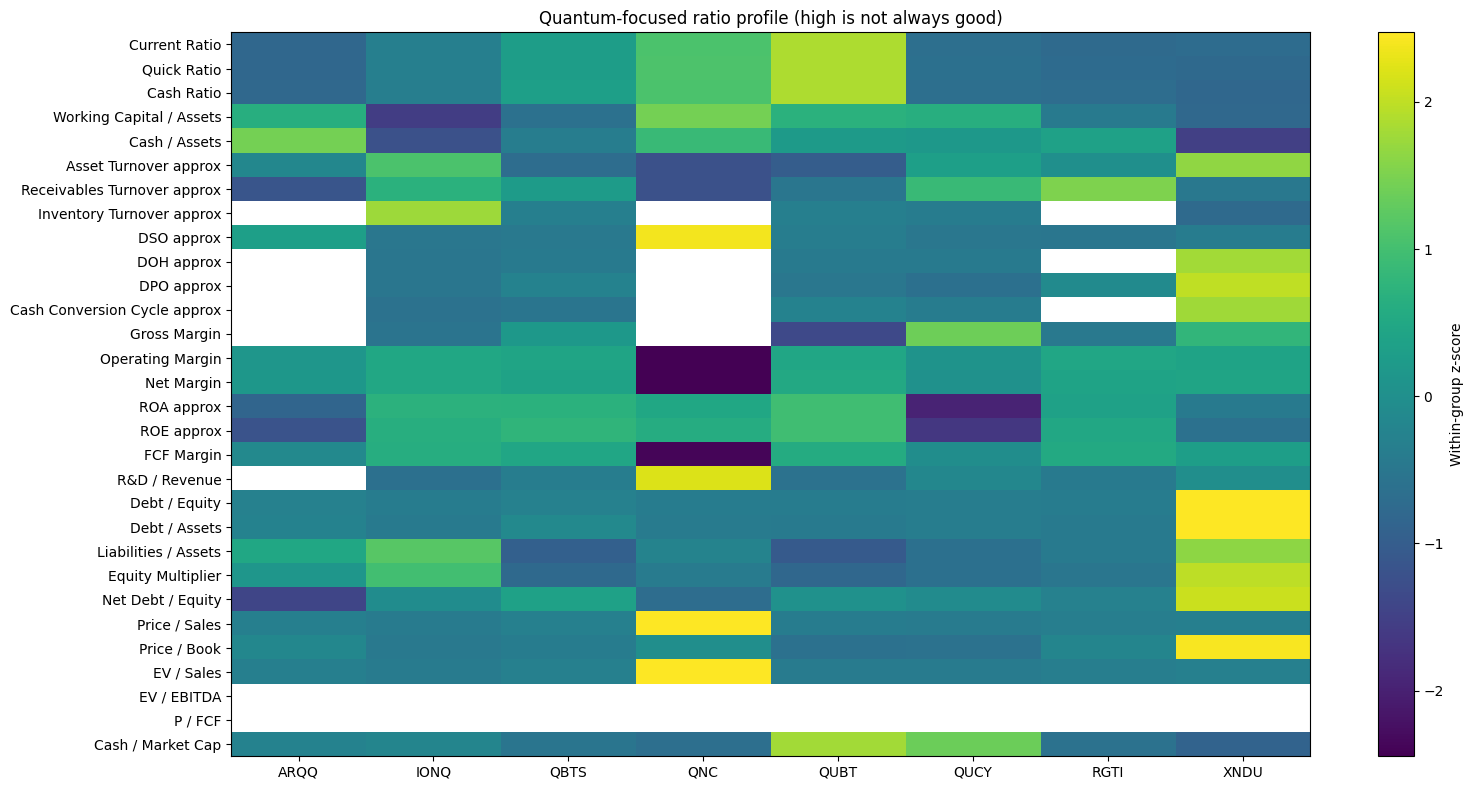

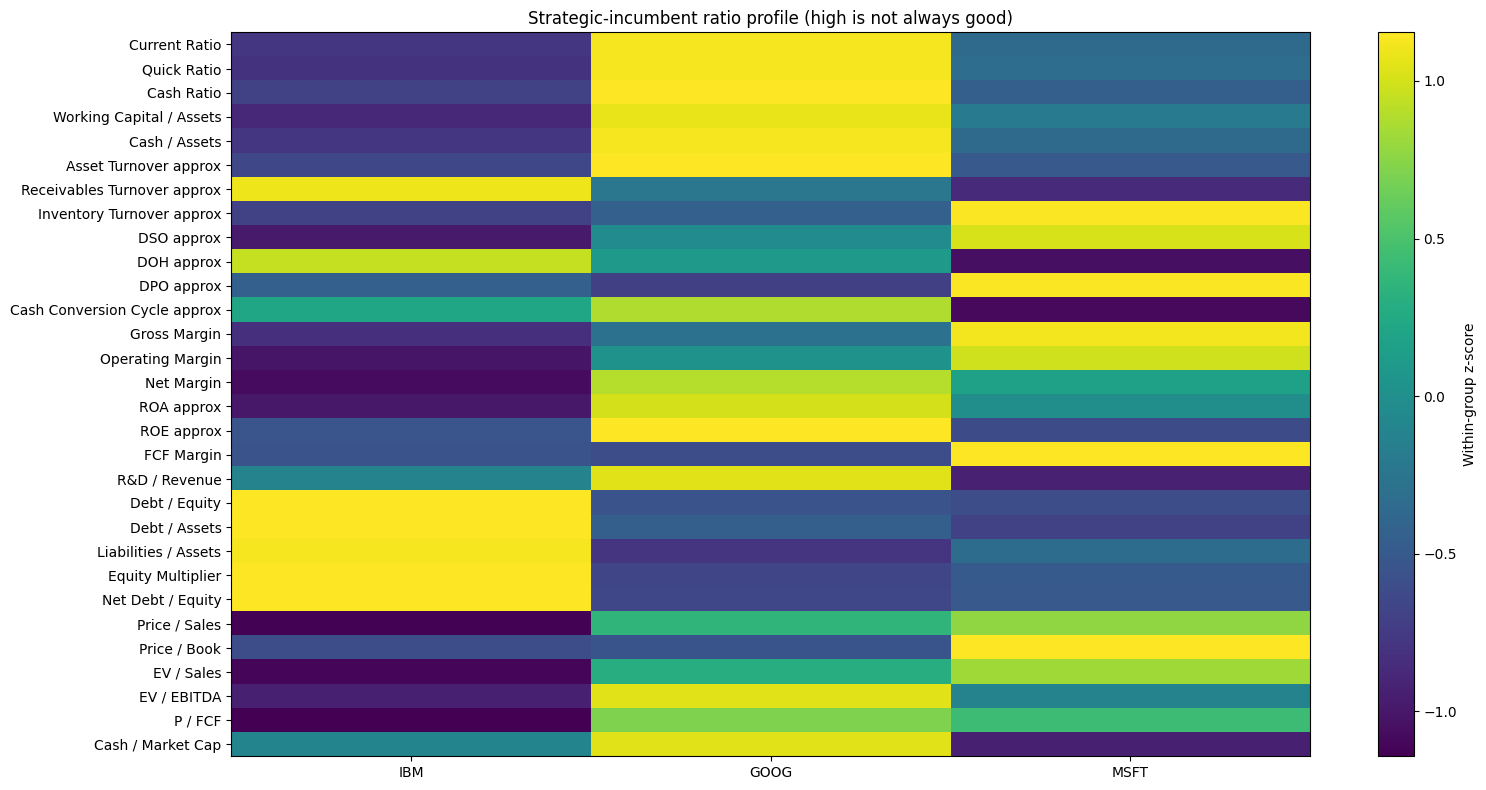

In [20]:
selected=sum(ratio_groups.values(),[])
def standardized_ratio_heatmap(tickers,title):
    Z=fin_snapshot.loc[tickers,selected].copy()
    for c in Z:
        valid=Z[c].dropna()
        if len(valid)>=3:
            lo,hi=valid.quantile([.05,.95]); Z[c]=Z[c].clip(lo,hi)
        sd=Z[c].std(); Z[c]=(Z[c]-Z[c].mean())/sd if pd.notna(sd) and sd>0 else np.nan
    fig,ax=plt.subplots(figsize=(16,8)); im=ax.imshow(Z.T.values,aspect='auto'); ax.set_xticks(range(len(Z))); ax.set_xticklabels(Z.index); ax.set_yticks(range(len(Z.columns))); ax.set_yticklabels(Z.columns); fig.colorbar(im,ax=ax,label='Within-group z-score'); ax.set_title(title+' (high is not always good)'); plt.tight_layout(); plt.show()
standardized_ratio_heatmap(CORE_QUANTUM,'Quantum-focused ratio profile'); standardized_ratio_heatmap(STRATEGIC_INCUMBENTS,'Strategic-incumbent ratio profile')


### Ratio histories and cross-sectional ratio visualizations

Historical ratios are shown from 2020 onward. Startup vendor ratios are used where available; R&D intensity is reconstructed from statements. Incumbent ratios are calculated directly from the added quarterly data.

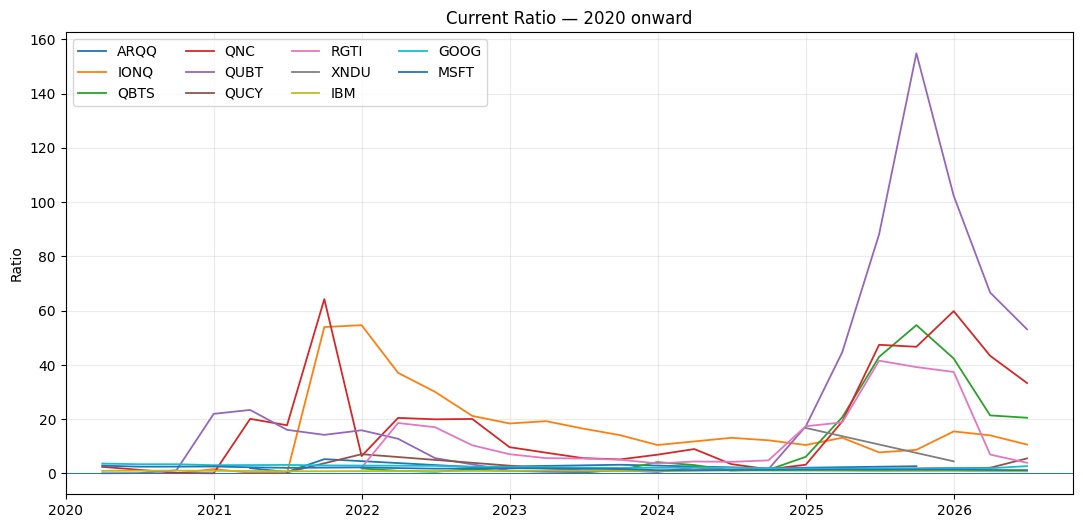

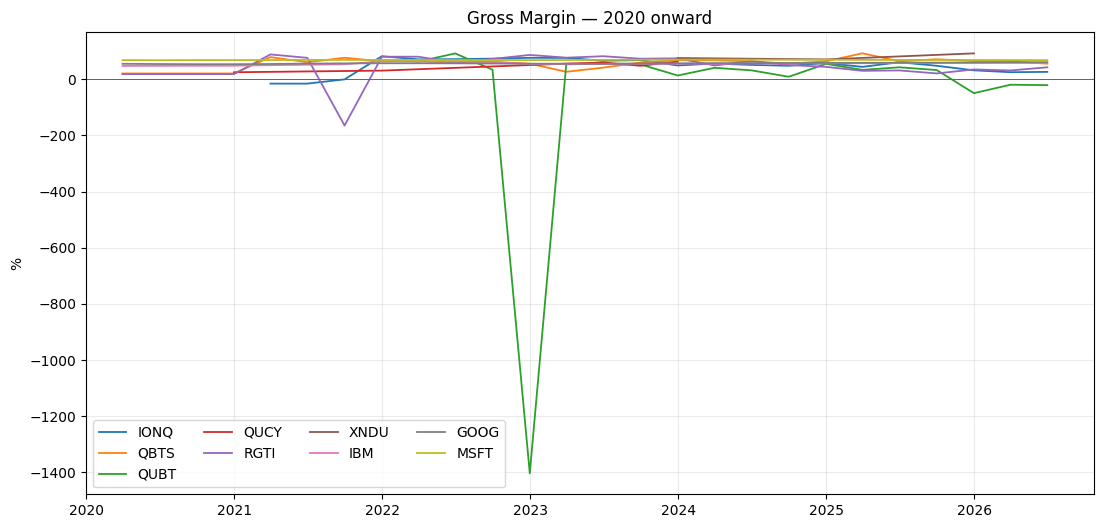

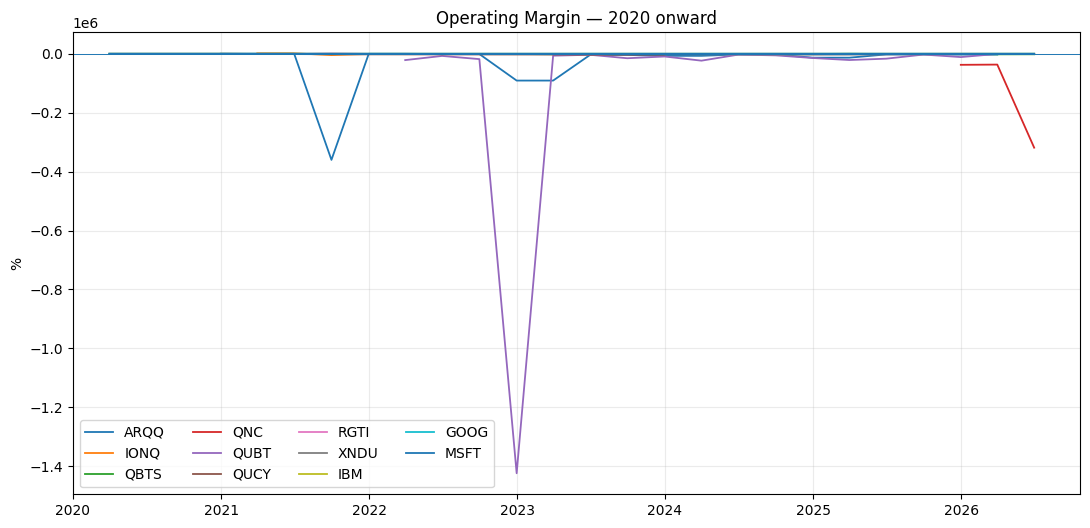

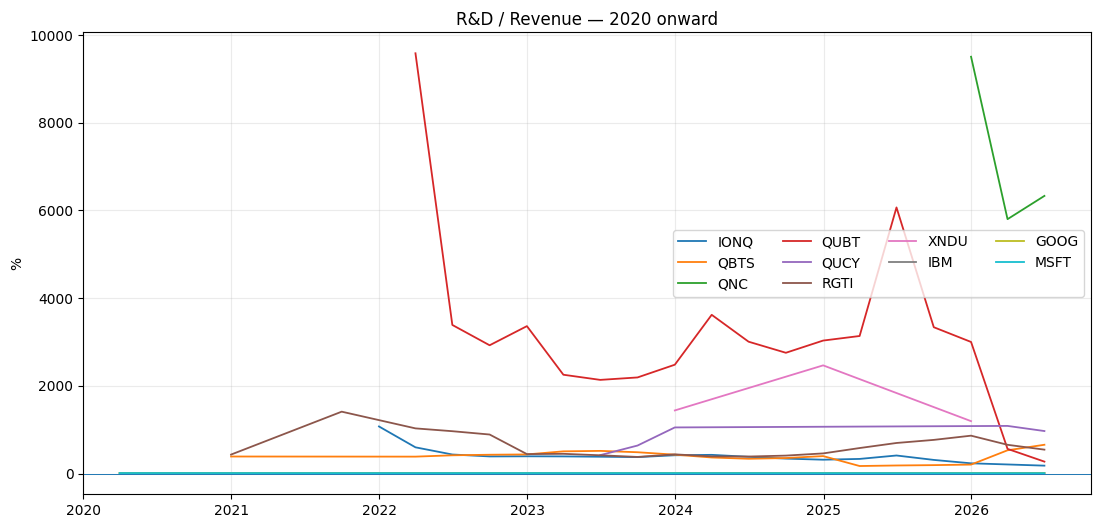

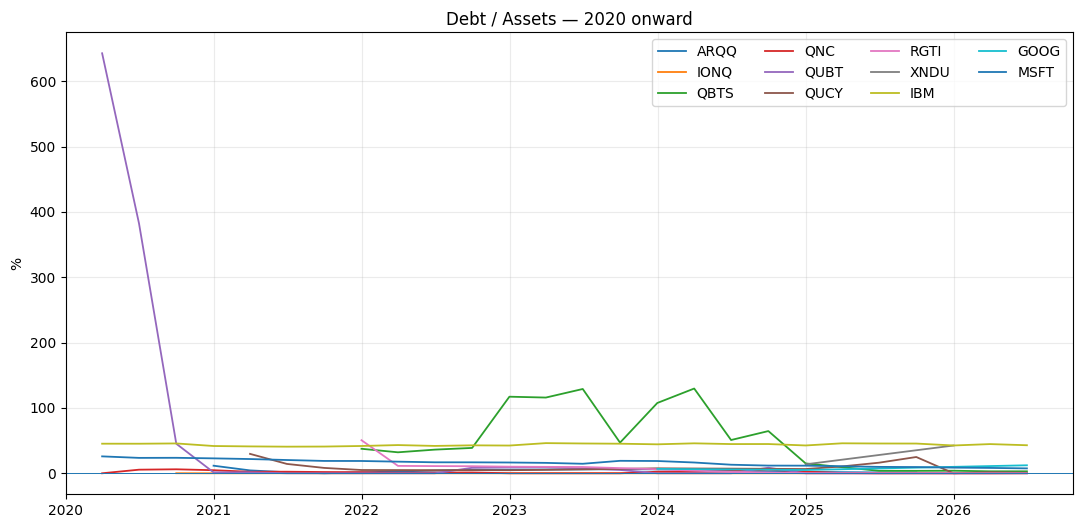

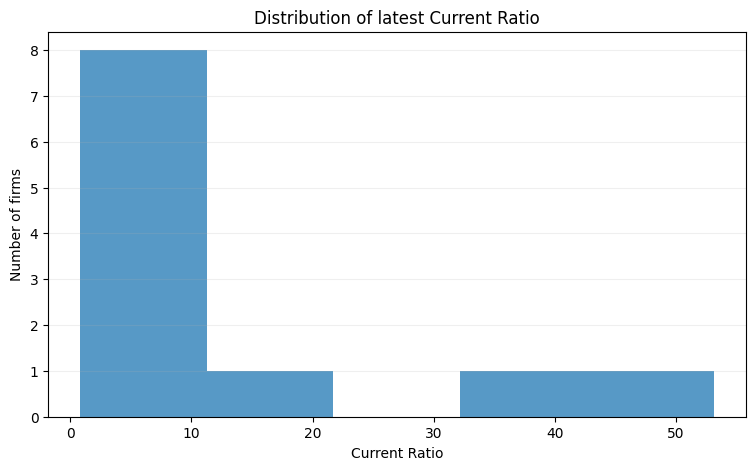

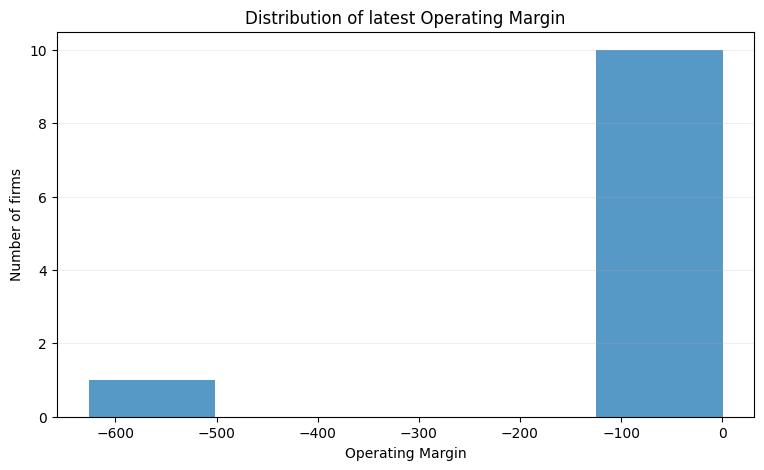

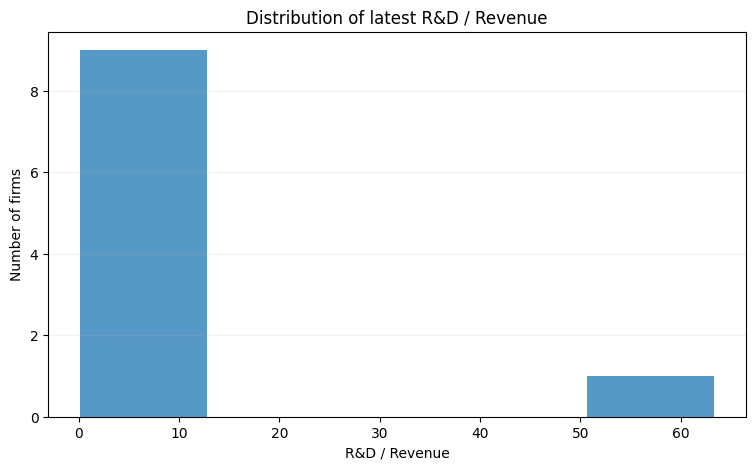

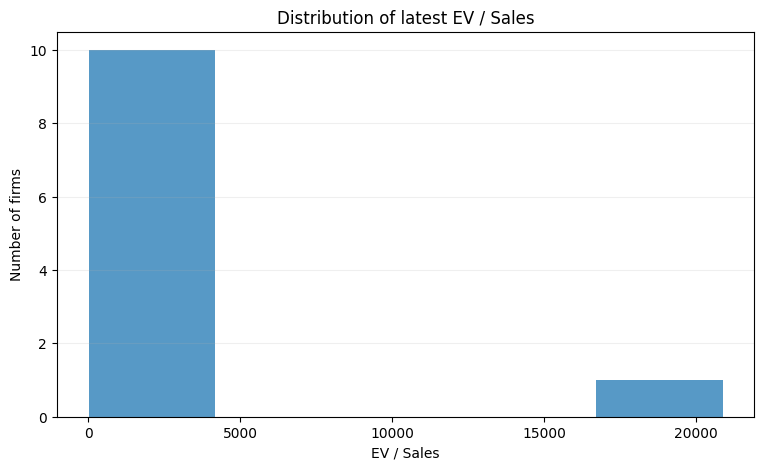

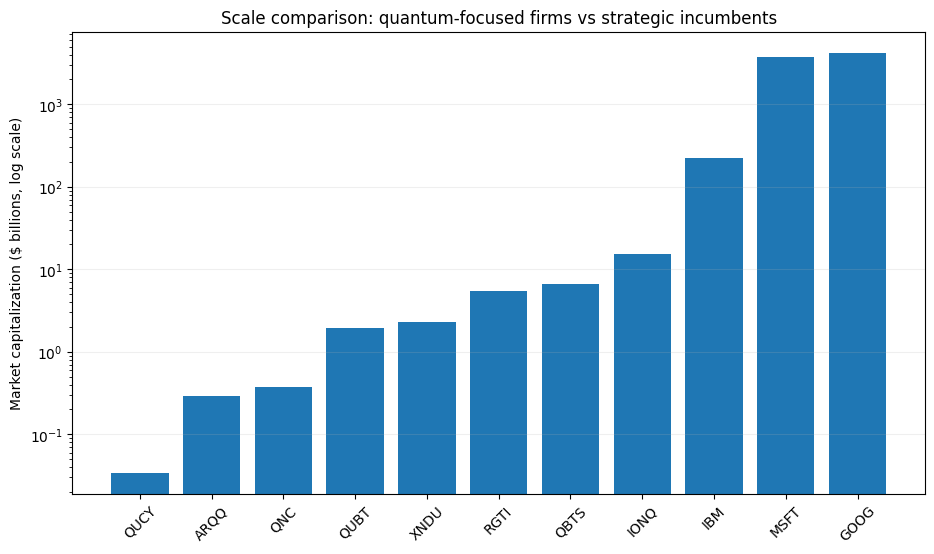

In [21]:
def _roll(s,n=4): return s.sort_index().rolling(n,min_periods=n).sum()
def ratio_history(t,metric):
    if t=='XNDU':
        vals={};
        for y,x in XNDU_ANNUAL.iterrows():
            if y<2020: continue
            if metric=='Current Ratio': v=safe_div(x.get('Current Assets'),x.get('Current Liabilities'))
            elif metric=='Gross Margin': v=100*safe_div(x.get('Revenue')-x.get('Cost of Revenue'),x.get('Revenue'))
            elif metric=='Operating Margin': v=100*safe_div(x.get('Operating Income'),x.get('Revenue'))
            elif metric=='R&D / Revenue': v=100*safe_div(x.get('R&D'),x.get('Revenue'))
            elif metric=='Debt / Assets': v=100*safe_div(x.get('Long-term Debt'),x.get('Total Assets'))
            else: v=np.nan
            vals[pd.Timestamp(f'{int(y)}-12-31')]=v
        return pd.Series(vals,dtype=float)
    if t in STRATEGIC_INCUMBENTS:
        if metric=='Current Ratio': return (inc_metric_series(t,'Balance Sheet','Current Assets')/inc_metric_series(t,'Balance Sheet','Current Liabilities')).loc[PLOT_START:]
        if metric in ['Gross Margin','Operating Margin','R&D / Revenue']:
            rev=_roll(inc_metric_series(t,'Income Statement','Total Revenue')); num={'Gross Margin':_roll(inc_metric_series(t,'Income Statement','Gross Profit')),'Operating Margin':_roll(inc_metric_series(t,'Income Statement','Operating Income')),'R&D / Revenue':_roll(inc_metric_series(t,'Income Statement','Research & Development'))}[metric]; return (100*num/rev).loc[PLOT_START:]
        if metric=='Debt / Assets': return (100*inc_metric_series(t,'Balance Sheet','Total Debt')/inc_metric_series(t,'Balance Sheet','Total Assets')).loc[PLOT_START:]
    if t in financials:
        mp={'Current Ratio':'Current Ratio','Gross Margin':'Gross Margin','Operating Margin':'Operating Margin','Debt / Assets':'Total Debt / Assets %'}
        if metric in mp: return metric_series(t,'Ratio Analysis',mp[metric],False).loc[PLOT_START:]
        if metric=='R&D / Revenue':
            n=PERIODS_PER_TTM.get(t,4); return (100*_roll(metric_series(t,'Income Statement','Research & Development',True),n)/_roll(metric_series(t,'Income Statement','Total Revenue',True),n)).loc[PLOT_START:]
    return pd.Series(dtype=float)
for metric,kind in [('Current Ratio','ratio'),('Gross Margin','percent'),('Operating Margin','percent'),('R&D / Revenue','percent'),('Debt / Assets','percent')]:
    plt.figure(figsize=(13,6))
    for t in TICKERS:
        s=ratio_history(t,metric).dropna()
        if len(s): plt.plot(s.index,s,label=t,linewidth=1.3)
    plt.xlim(left=PLOT_START); plt.axhline(0,linewidth=.7); plt.title(f'{metric} — 2020 onward'); plt.ylabel('%' if kind=='percent' else 'Ratio'); plt.legend(ncol=4); plt.grid(alpha=.25); plt.show()
for metric in ['Current Ratio','Operating Margin','R&D / Revenue','EV / Sales']:
    v=fin_snapshot[metric].replace([np.inf,-np.inf],np.nan).dropna(); plt.figure(figsize=(9,5)); plt.hist(v.values,bins=min(8,max(4,len(v)//2)),alpha=.75); plt.title(f'Distribution of latest {metric}'); plt.xlabel(metric); plt.ylabel('Number of firms'); plt.grid(axis='y',alpha=.2); plt.show()
mcap=(fin_snapshot['Market Cap $000']/1e6).dropna().sort_values(); plt.figure(figsize=(11,6)); plt.bar(mcap.index,mcap.values); plt.yscale('log'); plt.ylabel('Market capitalization ($ billions, log scale)'); plt.title('Scale comparison: quantum-focused firms vs strategic incumbents'); plt.xticks(rotation=45); plt.grid(axis='y',alpha=.2); plt.show()


### Accounting-based operating similarity network

This is **not** a supplier-customer map. It visualizes similarity in working-capital structure using DSO, DOH, DPO, cash conversion cycle, current ratio, receivables turnover, and payables turnover. Variables are standardized, missing values are median-filled, and firms are linked to their nearest accounting neighbors. Similarity can motivate further research into actual commercial relationships but does not establish them.

Ticker,ARQQ,IONQ,QBTS,QNC,QUBT,QUCY,RGTI,XNDU,IBM,GOOG,MSFT
Ticker,,,,,,,,,,,
ARQQ,0.0000,1.1347,1.5543,3.3672,3.2550,1.0304,1.5362,6.1308,3.8214,3.3543,1.6398
IONQ,1.1347,0.0000,1.2810,3.8341,2.7443,0.6394,1.4519,6.2903,3.0981,2.6210,1.1930
QBTS,1.5543,1.2810,0.0000,3.6496,2.2493,1.2453,1.1971,5.8977,3.8983,3.7541,1.6736
QNC,3.3672,3.8341,3.6496,0.0000,3.6233,3.9679,4.1920,7.2047,5.5659,5.1952,4.3217
QUBT,3.2550,2.7443,2.2493,3.6233,0.0000,3.0323,3.3815,6.6278,4.8296,4.4067,3.5506
QUCY,1.0304,0.6394,1.2453,3.9679,3.0323,0.0000,1.1119,6.0330,3.2020,2.9308,0.9975
RGTI,1.5362,1.4519,1.1971,4.1920,3.3815,1.1119,0.0000,5.8020,3.4438,3.5753,0.9506
XNDU,6.1308,6.2903,5.8977,7.2047,6.6278,6.0330,5.8020,0.0000,7.4566,7.4248,6.3384
IBM,3.8214,3.0981,3.8983,5.5659,4.8296,3.2020,3.4438,7.4566,0.0000,1.6863,2.6020


,Degree Centrality,Weighted Strength,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,PageRank
Ticker,,,,,,
QUCY,0.5000,2.5220,0.4667,0.3762,0.5820,0.1802
RGTI,0.4000,1.5883,0.2000,0.3352,0.4004,0.1208
IONQ,0.4000,1.6217,0.2667,0.3484,0.3702,0.1248
MSFT,0.3000,1.2909,0.1778,0.3210,0.3418,0.0997
QBTS,0.4000,1.3533,0.0444,0.3145,0.3252,0.1074
ARQQ,0.3000,1.1899,0.1778,0.3107,0.3125,0.0941
QUBT,0.3000,0.7911,0.0000,0.2262,0.1403,0.0706
GOOG,0.2000,0.6484,0.0000,0.2122,0.0877,0.0619
IBM,0.2000,0.6499,0.0000,0.2025,0.0838,0.0621


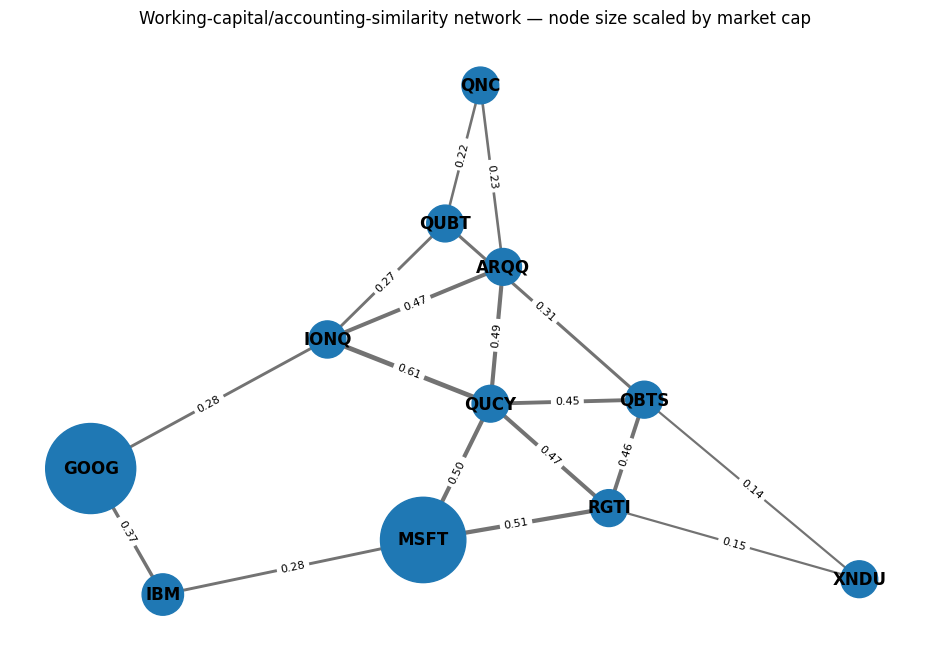

In [22]:
ACCOUNTING_NETWORK_FEATURES=['DSO approx','DOH approx','DPO approx','Cash Conversion Cycle approx','Current Ratio','Receivables Turnover approx','Payables Turnover approx']; ACCOUNTING_NETWORK_K=2
def accounting_similarity_network(features=ACCOUNTING_NETWORK_FEATURES,k=ACCOUNTING_NETWORK_K):
    X=fin_snapshot[features].replace([np.inf,-np.inf],np.nan).copy(); X=X.loc[:,X.notna().sum()>=4]; X=X.apply(lambda c:c.fillna(c.median()),axis=0)
    if X.shape[1]==0: return nx.Graph(),pd.DataFrame()
    Z=pd.DataFrame(StandardScaler().fit_transform(X),index=X.index,columns=X.columns); D=pd.DataFrame(index=Z.index,columns=Z.index,dtype=float); G=nx.Graph(); G.add_nodes_from(Z.index)
    for a in Z.index:
        for b in Z.index: D.loc[a,b]=np.linalg.norm(Z.loc[a]-Z.loc[b])
    for a in Z.index:
        for b,dist in D.loc[a].drop(a).sort_values().head(k).items(): G.add_edge(a,b,weight=1/(1+dist),distance=float(dist))
    return G,D
G_accounting,D_accounting=accounting_similarity_network(); display(D_accounting); acct_cent=network_centrality_table(G_accounting); display(acct_cent)
plt.figure(figsize=(12,8)); pos=nx.spring_layout(G_accounting,seed=42,weight='weight'); sizes=_scaled_node_sizes(fin_snapshot['Market Cap $000'].reindex(list(G_accounting.nodes()))); nx.draw_networkx_nodes(G_accounting,pos,node_size=[sizes[n] for n in G_accounting]); nx.draw_networkx_labels(G_accounting,pos,font_weight='bold'); nx.draw_networkx_edges(G_accounting,pos,width=[1+4*G_accounting[u][v]['weight'] for u,v in G_accounting.edges()],alpha=.55); nx.draw_networkx_edge_labels(G_accounting,pos,edge_labels={(u,v):f"{d['weight']:.2f}" for u,v,d in G_accounting.edges(data=True)},font_size=8); plt.title('Working-capital/accounting-similarity network — node size scaled by market cap'); plt.axis('off'); plt.show()


## 10. Growth, margins, cash burn, and dilution histories

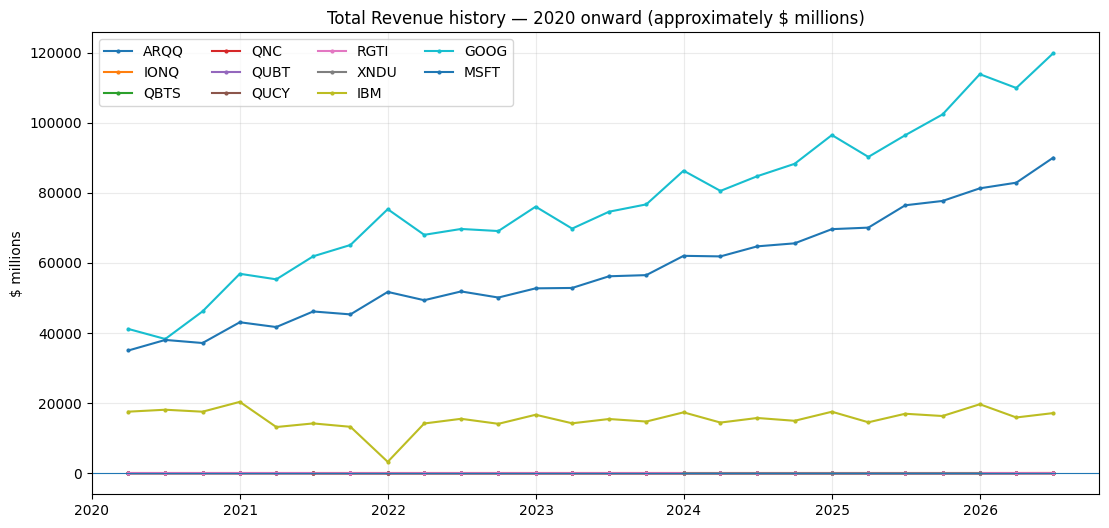

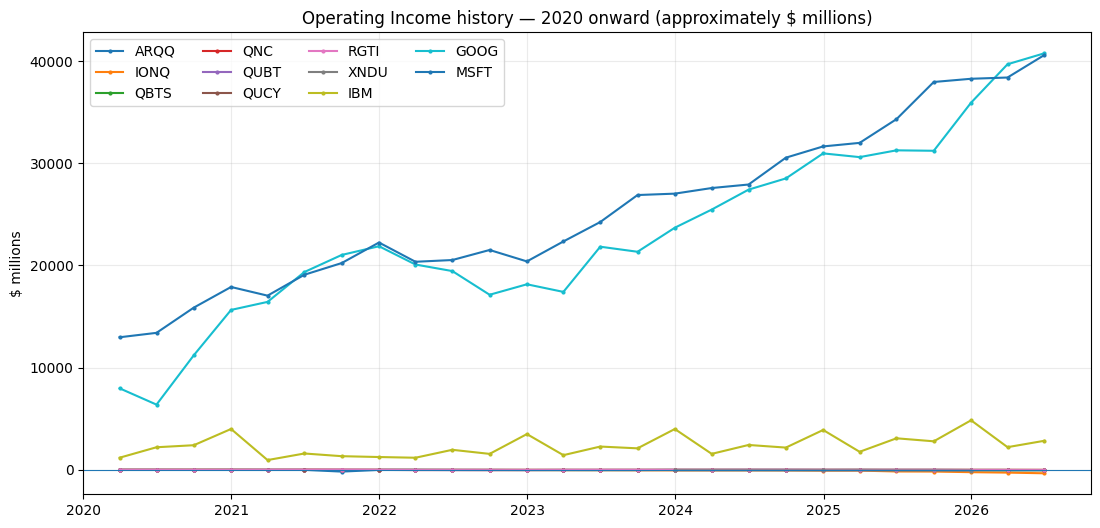

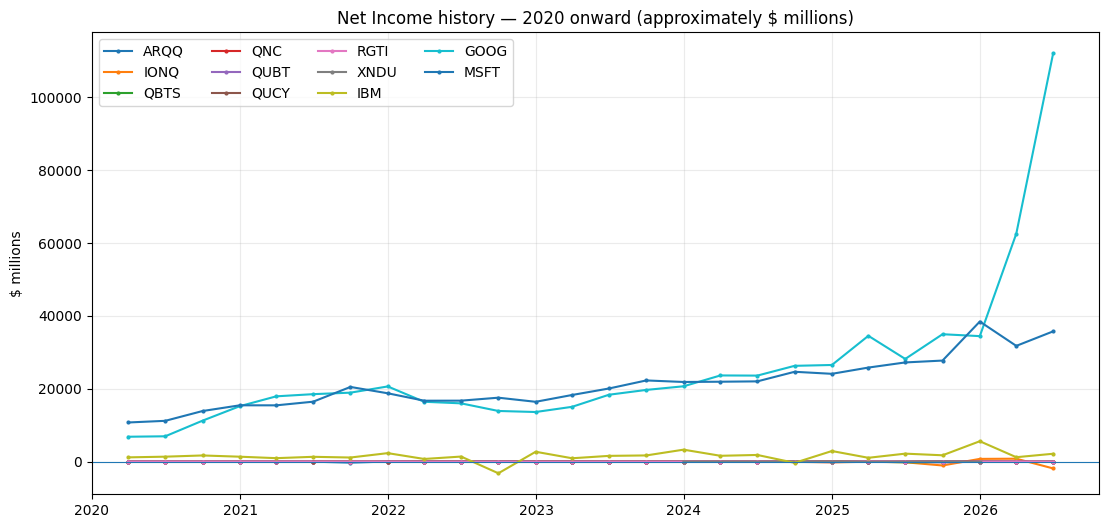

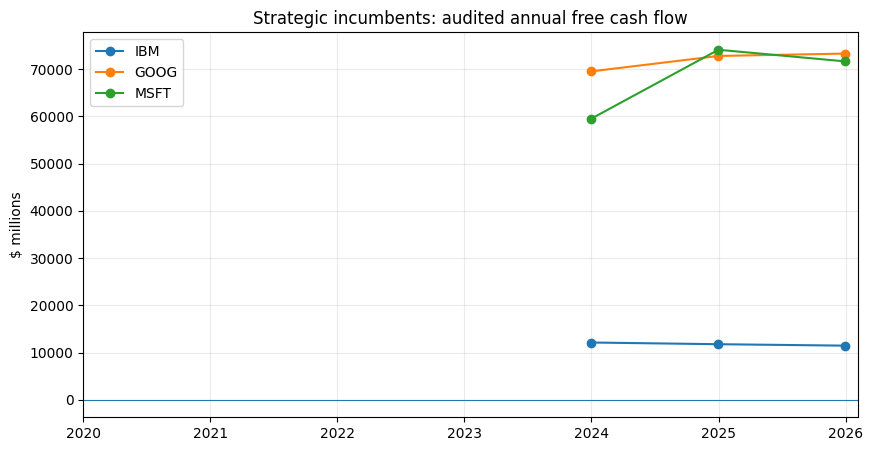

In [23]:
def statement_history(ticker,metric):
    if ticker=='XNDU':
        mp={'Total Revenue':'Revenue','Operating Income':'Operating Income','Net Income':'Net Income'}
        if metric in mp:
            s=XNDU_ANNUAL[mp[metric]].copy(); s.index=pd.to_datetime(s.index.astype(str)+'-12-31'); return s.loc[PLOT_START:]
        return pd.Series(dtype=float)
    if ticker in STRATEGIC_INCUMBENTS:
        mp={'Total Revenue':'Total Revenue','Operating Income':'Operating Income','Net Income':'Net Income Common Stockholders'}; return inc_metric_series(ticker,'Income Statement',mp[metric]).loc[PLOT_START:]
    return metric_series(ticker,'Income Statement',metric,True).loc[PLOT_START:]
for metric in ['Total Revenue','Operating Income','Net Income']:
    plt.figure(figsize=(13,6))
    for t in TICKERS:
        s=statement_history(t,metric)
        if len(s): plt.plot(s.index,s.values/1000,label=t,marker='o',markersize=2)
    plt.xlim(left=PLOT_START); plt.axhline(0,linewidth=.8); plt.title(f'{metric} history — 2020 onward (approximately $ millions)'); plt.ylabel('$ millions'); plt.legend(ncol=4); plt.grid(alpha=.25); plt.show()
plt.figure(figsize=(10,5))
for t in STRATEGIC_INCUMBENTS:
    s=INCUMBENT_CASHFLOW_ANNUAL[t]['FCF $000']/1000; plt.plot(pd.to_datetime(s.index.astype(str)+'-12-31'),s.values,label=t,marker='o')
plt.xlim(left=PLOT_START); plt.axhline(0,linewidth=.8); plt.title('Strategic incumbents: audited annual free cash flow'); plt.ylabel('$ millions'); plt.legend(); plt.grid(alpha=.25); plt.show()


,Peer group,FCF basis,TTM Revenue $000,FCF $000 (TTM/latest FY),Cash+ST Inv $000,Cash Runway Years (FCF burn),Shares Out 000,Revenue Growth approx,FCF Growth approx
Ticker,,,,,,,,,
ARQQ,Quantum-focused,Vendor TTM,624.0000,"-21,536.0000","36,978.0000",1.7170,"15,000.0000",0.3448,NaN
IONQ,Quantum-focused,Vendor TTM,"246,474.0000","-484,227.0000","2,118,969.0000",4.3760,"381,044.0000",3.7064,NaN
QBTS,Quantum-focused,Vendor TTM,"12,425.0000","-119,076.0000","546,215.0000",4.5871,"372,011.0000",-0.4422,NaN
QNC,Quantum-focused,Vendor TTM,16.7850,"-2,991.0000","23,953.8390",8.0086,"219,420.0000",NaN,NaN
QUBT,Quantum-focused,Vendor TTM,"9,824.0000","-51,478.0000","954,170.0000",18.5355,"225,494.0000",36.3536,NaN
QUCY,Quantum-focused,Vendor TTM,396.4300,"-12,031.0000","13,376.0400",1.1118,"24,929.0000",-0.7475,NaN
RGTI,Quantum-focused,Vendor TTM,"13,353.0000","-87,582.0000","393,709.0000",4.4953,"333,677.0000",0.6849,NaN
XNDU,Quantum-focused,FY2025 audited annual report,"4,617.0000","-74,224.0000","16,164.0000",0.2178,"298,511.3640",1.9056,NaN
IBM,Strategic incumbent,FY2025 audited annual report,"69,097,000.0000","11,455,000.0000","8,132,000.0000",NaN,"942,134.3900",0.0790,-0.0259


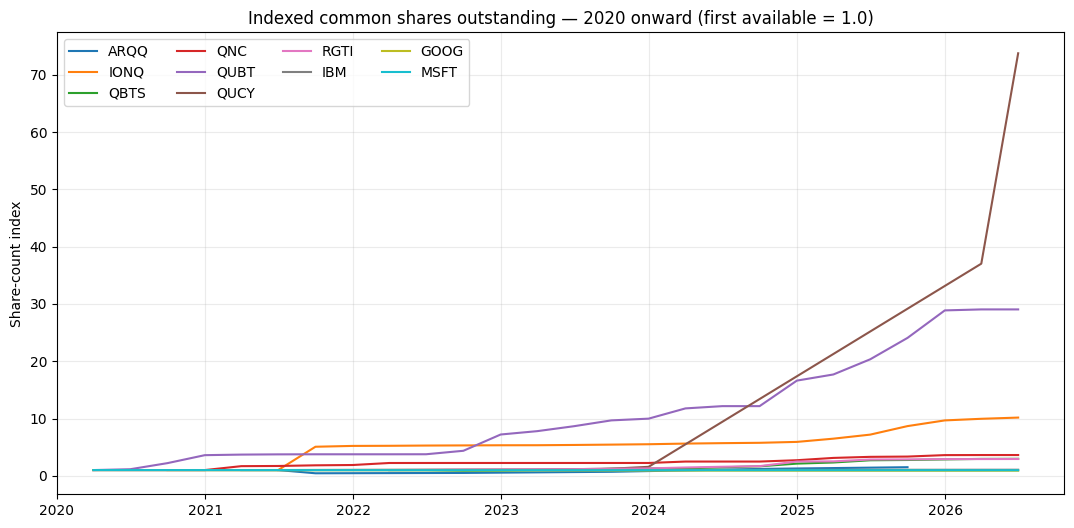

In [24]:
cols=['Peer group','FCF basis','TTM Revenue $000','FCF $000 (TTM/latest FY)','Cash+ST Inv $000','Cash Runway Years (FCF burn)','Shares Out 000','Revenue Growth approx','FCF Growth approx']; display(fin_snapshot[cols])
plt.figure(figsize=(13,6))
for t in TICKERS:
    if t in financials: s=metric_series(t,'Balance Sheet','Total Common Shares Outstanding',True).loc[PLOT_START:]
    elif t in STRATEGIC_INCUMBENTS: s=inc_metric_series(t,'Balance Sheet','Ordinary Shares Number').loc[PLOT_START:]
    else: s=pd.Series(dtype=float)
    s=s.dropna()
    if len(s): plt.plot(s.index,s/s.iloc[0],label=t)
plt.xlim(left=PLOT_START); plt.title('Indexed common shares outstanding — 2020 onward (first available = 1.0)'); plt.ylabel('Share-count index'); plt.legend(ncol=4); plt.grid(alpha=.25); plt.show()


### A note on growth rates with negative earnings and FCF

Percentage growth rates become misleading when the denominator changes sign or is close to zero. The notebook therefore reports conventional revenue growth broadly, but does **not** mechanically label a change from a large loss to a smaller loss as a positive “earnings growth rate.” For loss-making firms, inspect the level charts, margins, cash burn, runway, R&D intensity, and dilution instead.

## 11. Cost of equity, cost of debt, and WACC

In [25]:
def estimate_interest_expense_ttm(t):
    if t in STRATEGIC_INCUMBENTS:
        x=inc_ttm(t,'Interest Expense Non Operating'); x=inc_ttm(t,'Interest Expense') if pd.isna(x) else x; return abs(x) if pd.notna(x) else np.nan
    s=metric_series(t,'Income Statement','Interest Exp.(Inc.), Net-Operating, Total',True).dropna().sort_index(); n=PERIODS_PER_TTM.get(t,4)
    if len(s):
        x=s.tail(n).sum(); return abs(x) if pd.notna(x) and x!=0 else np.nan
    return np.nan
def wacc_row(t):
    beta=ff_table.loc[t,'CAPM beta'] if t in ff_table.index else np.nan; ke=FORWARD_RF+beta*FORWARD_ERP if pd.notna(beta) else np.nan; debt=fin_snapshot.loc[t,'Debt $000']; equity=fin_snapshot.loc[t,'Market Cap $000']; interest=estimate_interest_expense_ttm(t); kd_obs=safe_div(interest,debt) if pd.notna(debt) and debt>0 else np.nan; kd=COST_DEBT_OVERRIDE.get(t,np.nan); source='manual override'
    if pd.isna(kd): kd=kd_obs; source='observed TTM interest expense / latest debt'
    if pd.isna(kd) and pd.notna(debt) and debt>0: kd=DEFAULT_PRETAX_COST_DEBT; source='illustrative default'
    if pd.notna(debt) and debt==0: kd=0.; source='debt-free'
    V=(equity if pd.notna(equity) else 0)+(debt if pd.notna(debt) else 0); we=safe_div(equity,V); wd=safe_div(debt,V); wacc=we*ke+wd*kd*(1-TAX_RATE) if all(pd.notna(v) for v in [we,ke,wd,kd]) else np.nan
    return {'Ticker':t,'Peer group':PEER_GROUP[t],'CAPM beta':beta,'Forward RF':FORWARD_RF,'ERP':FORWARD_ERP,'Cost of Equity':ke,'Debt $000':debt,'TTM interest expense proxy $000':interest,'Observed Cost of Debt':kd_obs,'Cost of Debt Used':kd,'Cost of Debt Source':source,'Equity Weight':we,'Debt Weight':wd,'WACC':wacc}
wacc_table=pd.DataFrame([wacc_row(t) for t in TICKERS]).set_index('Ticker'); display(wacc_table)


,Peer group,CAPM beta,Forward RF,ERP,Cost of Equity,Debt $000,TTM interest expense proxy $000,Observed Cost of Debt,Cost of Debt Used,Cost of Debt Source,Equity Weight,Debt Weight,WACC
Ticker,,,,,,,,,,,,,
ARQQ,Quantum-focused,1.6376,0.0400,0.0500,0.1219,754.0000,"3,000.0000",3.9788,3.9788,observed TTM interest expense / latest debt,0.9974,0.0026,0.1296
IONQ,Quantum-focused,2.8010,0.0400,0.0500,0.1801,0.0000,NaN,NaN,0.0000,debt-free,1.0000,0.0000,0.1801
QBTS,Quantum-focused,2.3379,0.0400,0.0500,0.1569,"35,032.0000",NaN,NaN,0.0800,illustrative default,0.9947,0.0053,0.1564
QNC,Quantum-focused,3.2750,0.0400,0.0500,0.2037,112.5950,21.4000,0.1901,0.1901,observed TTM interest expense / latest debt,0.9997,0.0003,0.2037
QUBT,Quantum-focused,1.4914,0.0400,0.0500,0.1146,0.0000,NaN,NaN,0.0000,debt-free,1.0000,0.0000,0.1146
QUCY,Quantum-focused,5.4299,0.0400,0.0500,0.3115,168.6700,NaN,NaN,0.0800,illustrative default,0.9951,0.0049,0.3103
RGTI,Quantum-focused,2.5262,0.0400,0.0500,0.1663,0.0000,NaN,NaN,0.0000,debt-free,1.0000,0.0000,0.1663
XNDU,Quantum-focused,5.2474,0.0400,0.0500,0.3024,"29,998.0000",NaN,NaN,0.0800,illustrative default,0.9871,0.0129,0.2993
IBM,Strategic incumbent,0.7464,0.0400,0.0500,0.0773,"65,272,000.0000","1,929,000.0000",0.0296,0.0296,observed TTM interest expense / latest debt,0.7743,0.2257,0.0651


**WACC interpretation.** Cost of equity uses an estimated market beta but a user-set forward risk-free rate and equity risk premium. This deliberately separates historical beta estimation from forward discount-rate assumptions. Cost of debt is inferred only from an explicit operating interest-expense line when available. If debt exists but the filings/vendor panel do not provide a clean interest-expense numerator, the notebook uses the clearly labeled `DEFAULT_PRETAX_COST_DEBT` scenario assumption (8% initially), which can be overridden by ticker. For essentially debt-free firms, WACC reduces to the cost of equity.

### Return networks with market-cap node sizing

Now that share-count data are loaded, the same return networks can be redrawn with node size scaled to market capitalization. This makes the incumbents' economic scale explicit while leaving edge formation entirely return-based.

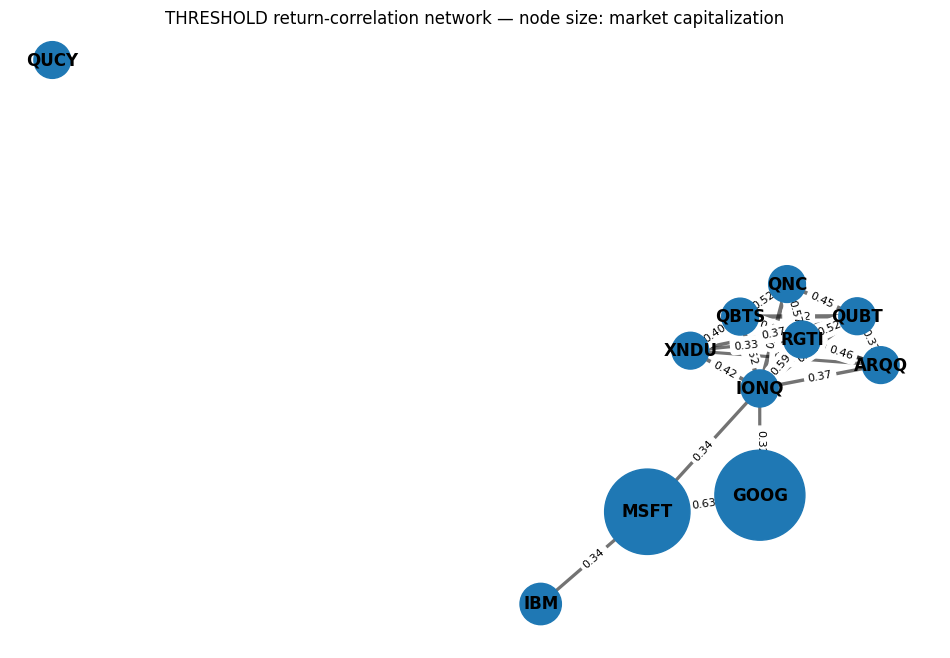

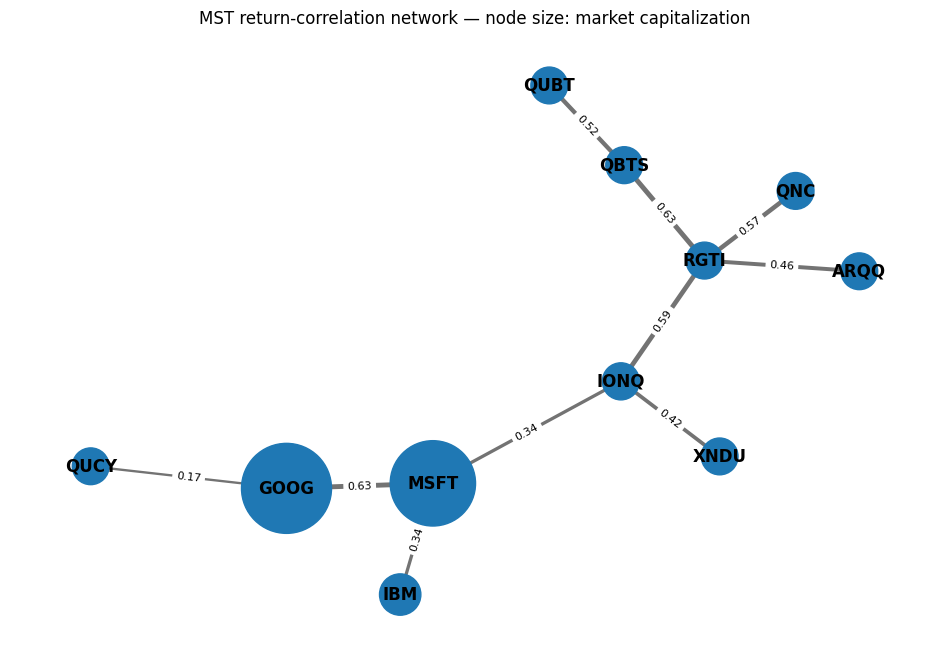

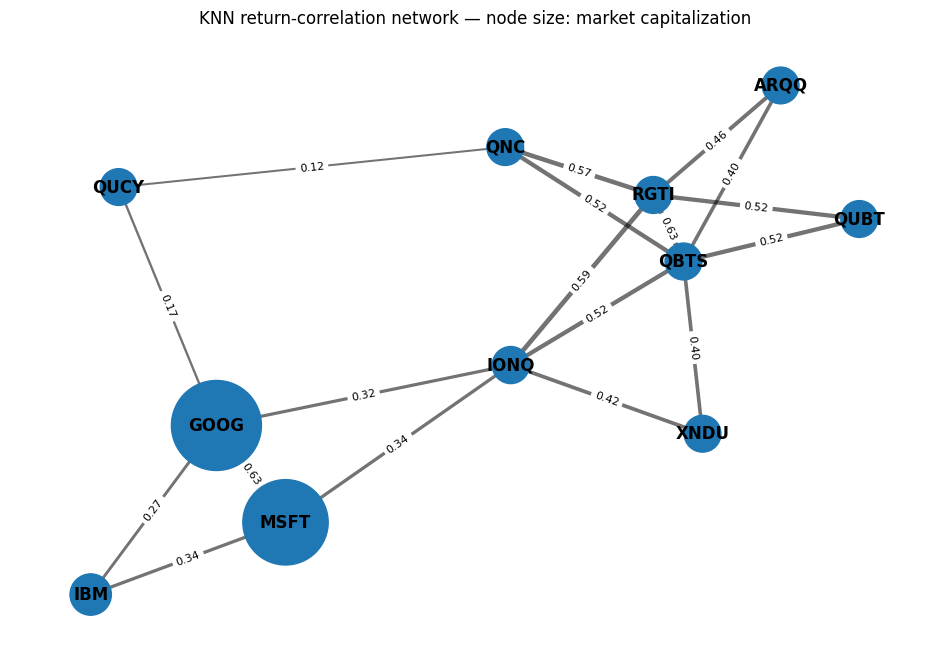

In [26]:
market_caps=fin_snapshot['Market Cap $000'].to_dict()
for gt in NETWORK_GRAPH_TYPES: plot_return_network(gt,'market_cap',market_caps)

## 12. JKP 153-factor analysis: contemporaneous importance and lagged predictability

In [27]:
def jkp_date_bounds(path, chunksize=500_000):
    mn=None; mx=None; names=set(); n=0
    for ch in pd.read_csv(path,usecols=['name','date'],chunksize=chunksize):
        names.update(ch['name'].dropna().unique())
        d=pd.to_datetime(ch['date'],errors='coerce').dropna()
        if len(d):
            mn=d.min() if mn is None else min(mn,d.min())
            mx=d.max() if mx is None else max(mx,d.max())
        n+=len(ch)
    return mn,mx,len(names),n
jkp_min,jkp_max,jkp_nfac,jkp_nrows=jkp_date_bounds(JKP_PATH)
print(f'JKP: {jkp_nfac} factors, {jkp_nrows:,} long-format rows, {jkp_min.date()} to {jkp_max.date()}')

JKP: 153 factors, 3,123,546 long-format rows, 1926-01-02 to 2025-12-31


In [28]:
def load_jkp_panel(path,start,end,chunksize=400_000):
    start=pd.Timestamp(start); end=pd.Timestamp(end)
    keep=[]
    for ch in pd.read_csv(path,usecols=['date','name','ret'],chunksize=chunksize):
        ch['date']=pd.to_datetime(ch['date'],errors='coerce')
        z=ch[(ch['date']>=start)&(ch['date']<=end)].copy()
        if len(z): keep.append(z)
    if not keep: return pd.DataFrame()
    z=pd.concat(keep,ignore_index=True)
    z['ret']=pd.to_numeric(z['ret'],errors='coerce')
    return z.pivot_table(index='date',columns='name',values='ret',aggfunc='first').sort_index()

# Load only dates that can overlap the economically filtered stocks and the JKP file.
stock_start=min(d.index.min() for d in prices.values())
stock_end=max(d.index.max() for d in prices.values())
panel_start=max(stock_start,jkp_min)
panel_end=min(stock_end,jkp_max)
jkp=load_jkp_panel(JKP_PATH,panel_start,panel_end)
print('Wide JKP panel:',jkp.shape,'coverage',jkp.index.min().date() if len(jkp) else None,'to',jkp.index.max().date() if len(jkp) else None)

Wide JKP panel: (1508, 153) coverage 2020-01-02 to 2025-12-31


In [29]:
def _ridge_timeseries(X,y,min_obs=JKP_MIN_OBS):
    data=pd.concat([X,y.rename('y')],axis=1).dropna()
    if len(data)<min_obs: return None
    Xd=data.drop(columns='y'); yd=data['y']
    split=max(int(len(data)*.75),min_obs//2)
    if len(data)-split<30: split=int(len(data)*.70)
    Xtr,Xte=Xd.iloc[:split],Xd.iloc[split:]; ytr,yte=yd.iloc[:split],yd.iloc[split:]

    # Chronological inner validation chooses lambda without the cost of hundreds of CV fits.
    inner=max(int(len(Xtr)*.80),min_obs//2)
    if len(Xtr)-inner<20: inner=int(len(Xtr)*.70)
    Xin,Xval=Xtr.iloc[:inner],Xtr.iloc[inner:]; yin,yval=ytr.iloc[:inner],ytr.iloc[inner:]
    scaler_inner=StandardScaler().fit(Xin); Xin_s=scaler_inner.transform(Xin); Xval_s=scaler_inner.transform(Xval)
    alphas=np.logspace(-4,4,11); scores=[]
    for a in alphas:
        m=Ridge(alpha=a).fit(Xin_s,yin); pred=m.predict(Xval_s); scores.append(np.mean((yval-pred)**2))
    best_alpha=float(alphas[int(np.argmin(scores))])

    scaler=StandardScaler().fit(Xtr); Xtr_s=scaler.transform(Xtr); Xte_s=scaler.transform(Xte)
    model=Ridge(alpha=best_alpha).fit(Xtr_s,ytr); pred=model.predict(Xte_s)
    coef=pd.Series(model.coef_,index=Xd.columns)
    return {'coef':coef,'test_r2':r2_score(yte,pred),'n':len(data),'alpha':best_alpha,'model':model,'scaler':scaler}

def univariate_factor_tests(X,y):
    rows=[]
    for c in X.columns:
        d=pd.concat([y.rename('y'),X[c].rename('x')],axis=1).dropna(); n=len(d)
        if n<JKP_MIN_OBS: continue
        xv=d['x'].to_numpy(); yv=d['y'].to_numpy(); sx=np.std(xv,ddof=1); sy=np.std(yv,ddof=1)
        if sx<=1e-12 or sy<=1e-12: continue
        corr=np.corrcoef(xv,yv)[0,1]; beta=np.cov(xv,yv,ddof=1)[0,1]/np.var(xv,ddof=1); t=corr*np.sqrt((n-2)/max(1e-15,1-corr*corr)); p=2*stats.t.sf(abs(t),df=n-2)
        rows.append({'factor':c,'beta':beta,'t':t,'p':p,'corr':corr,'r2':corr*corr,'n':n})
    out=pd.DataFrame(rows)
    if len(out): out['q_fdr']=multipletests(out['p'].fillna(1),method='fdr_bh')[1]
    return out

def jkp_analysis_for_ticker(t):
    r=prices[t]['Return'].rename('stock'); d=pd.concat([r,jkp],axis=1,join='inner')
    if len(d)<JKP_MIN_OBS: return {'n':len(d),'message':f'Insufficient overlap ({len(d)} observations) under current return-start convention.'}
    y=d['stock']; X=d.drop(columns='stock'); usable=[c for c in X if X[c].notna().sum()>=JKP_MIN_OBS and X[c].std(skipna=True)>1e-12]; X=X[usable]
    return {'n':len(d),'uni_now':univariate_factor_tests(X,y),'reg_now':_ridge_timeseries(X,y),'uni_lag':univariate_factor_tests(X.shift(JKP_LAG),y),'reg_lag':_ridge_timeseries(X.shift(JKP_LAG),y)}

jkp_results={t:jkp_analysis_for_ticker(t) for t in TICKERS if t in prices}
for t,res in jkp_results.items():
    if 'message' in res: print(t,':',res['message'])
    else: print(t,': N=',res['n'],'OOS R2 contemporaneous=',f"{res['reg_now']['test_r2']:.3f}" if res['reg_now'] else None,'OOS R2 lagged=',f"{res['reg_lag']['test_r2']:.3f}" if res['reg_lag'] else None,'ridge alpha now=',f"{res['reg_now']['alpha']:.3g}" if res['reg_now'] else None)


ARQQ : N= 1085 OOS R2 contemporaneous= 0.097 OOS R2 lagged= 0.004 ridge alpha now= 1.58e+03
IONQ : N= 1067 OOS R2 contemporaneous= 0.293 OOS R2 lagged= 0.002 ridge alpha now= 1.58e+03
QBTS : N= 854 OOS R2 contemporaneous= 0.041 OOS R2 lagged= -0.168 ridge alpha now= 39.8
QNC : Insufficient overlap (0 observations) under current return-start convention.
QUBT : N= 1508 OOS R2 contemporaneous= 0.031 OOS R2 lagged= -0.011 ridge alpha now= 1e+04
QUCY : Insufficient overlap (0 observations) under current return-start convention.
RGTI : N= 963 OOS R2 contemporaneous= 0.237 OOS R2 lagged= -0.093 ridge alpha now= 251
XNDU : Insufficient overlap (0 observations) under current return-start convention.
IBM : N= 1508 OOS R2 contemporaneous= 0.037 OOS R2 lagged= -0.008 ridge alpha now= 1e+04
GOOG : N= 1508 OOS R2 contemporaneous= 0.447 OOS R2 lagged= -0.003 ridge alpha now= 251
MSFT : N= 1508 OOS R2 contemporaneous= 0.445 OOS R2 lagged= -0.016 ridge alpha now= 1e+04


In [30]:
def top_jkp_table(t,n=JKP_TOP_N):
    res=jkp_results.get(t,{})
    if 'message' in res or not res: return pd.DataFrame()
    now=res['uni_now'].set_index('factor') if len(res['uni_now']) else pd.DataFrame(); lag=res['uni_lag'].set_index('factor') if len(res['uni_lag']) else pd.DataFrame(); rn=res['reg_now']['coef'] if res.get('reg_now') else pd.Series(dtype=float); rl=res['reg_lag']['coef'] if res.get('reg_lag') else pd.Series(dtype=float); facs=sorted(set(now.index).union(lag.index).union(rn.index).union(rl.index)); z=pd.DataFrame(index=facs)
    z['Contemp corr']=now['corr'] if 'corr' in now else np.nan; z['Contemp t']=now['t'] if 't' in now else np.nan; z['Contemp q']=now['q_fdr'] if 'q_fdr' in now else np.nan; z['Contemp ridge coef']=rn; z['Lag corr']=lag['corr'] if 'corr' in lag else np.nan; z['Lag t']=lag['t'] if 't' in lag else np.nan; z['Lag q']=lag['q_fdr'] if 'q_fdr' in lag else np.nan; z['Lag ridge coef']=rl
    pct=pd.DataFrame({c:z[c].abs().rank(pct=True) for c in JKP_IMPORTANCE_WEIGHTS}); num=pd.Series(0.,index=z.index); den=pd.Series(0.,index=z.index)
    for c,w in JKP_IMPORTANCE_WEIGHTS.items():
        ok=pct[c].notna(); num.loc[ok]+=w*pct.loc[ok,c]; den.loc[ok]+=w
    z['Relative importance score (0-100)']=100*num/den.replace(0,np.nan)
    for c in pct: z[f'{c} percentile']=100*pct[c]
    return z.sort_values('Relative importance score (0-100)',ascending=False).head(n)
for t in TICKERS:
    tab=top_jkp_table(t)
    if len(tab): print('\n',t); display(tab)



 ARQQ


,Contemp corr,Contemp t,Contemp q,Contemp ridge coef,Lag corr,Lag t,Lag q,Lag ridge coef,Relative importance score (0-100),Contemp corr percentile,Contemp ridge coef percentile,Lag corr percentile,Lag ridge coef percentile
turnover_var_126d,-0.2097,-7.0584,0.0000,-0.0013,-0.0705,-2.3241,0.3800,-0.0004,96.0784,89.5425,98.0392,98.6928,98.0392
age,0.2610,8.8981,0.0000,0.0012,0.0665,2.1930,0.3800,0.0002,95.2614,100.0000,96.7320,96.7320,87.5817
dolvol_var_126d,-0.2219,-7.4883,0.0000,-0.0008,-0.0740,-2.4413,0.3800,-0.0003,92.8105,94.7712,82.3529,100.0000,94.1176
seas_6_10an,0.1018,3.3686,0.0016,0.0025,0.0577,1.9016,0.3800,0.0005,85.1307,50.9804,100.0000,89.5425,100.0000
capx_gr3,-0.1164,-3.8575,0.0003,-0.0009,-0.0717,-2.3660,0.3800,-0.0003,84.9673,57.5163,90.8497,99.3464,92.1569
market_equity,0.1565,5.2141,0.0000,0.0008,0.0528,1.7387,0.3800,0.0002,82.3529,72.5490,86.9281,81.6993,88.2353
ami_126d,0.1491,4.9627,0.0000,0.0008,0.0536,1.7656,0.3800,0.0002,79.5752,69.2810,81.0458,83.0065,84.9673
ivol_hxz4_21d,-0.2356,-7.9790,0.0000,-0.0008,-0.0672,-2.2157,0.3800,-0.0000,78.2680,98.6928,84.9673,97.3856,32.0261
ni_ar1,0.1124,3.7219,0.0005,0.0010,0.0489,1.6114,0.3800,0.0002,77.4510,56.2092,94.1176,72.5490,86.9281
capx_gr1,-0.0890,-2.9405,0.0058,-0.0010,-0.0502,-1.6529,0.3800,-0.0003,76.9608,42.4837,93.4641,75.1634,96.7320



 IONQ


,Contemp corr,Contemp t,Contemp q,Contemp ridge coef,Lag corr,Lag t,Lag q,Lag ridge coef,Relative importance score (0-100),Contemp corr percentile,Contemp ridge coef percentile,Lag corr percentile,Lag ridge coef percentile
seas_11_15na,-0.2664,-9.0194,0.0000,-0.0011,0.0650,2.1256,0.9654,0.0002,84.8039,48.3660,94.1176,100.0000,96.7320
niq_at,-0.3785,-13.3434,0.0000,-0.0008,-0.0260,-0.8500,0.9654,-0.0001,77.2876,70.5882,86.9281,78.4314,73.2026
noa_at,0.1811,6.0092,0.0000,0.0012,-0.0457,-1.4921,0.9654,-0.0001,76.9608,32.6797,96.7320,94.7712,83.6601
ncol_gr1a,-0.3085,-10.5857,0.0000,-0.0007,-0.0379,-1.2379,0.9654,-0.0001,76.9608,54.9020,80.3922,92.1569,80.3922
qmj_safety,-0.4160,-14.9307,0.0000,-0.0013,0.0164,0.5364,0.9654,0.0001,76.7974,79.7386,98.0392,52.9412,76.4706
opex_at,0.2383,8.0074,0.0000,0.0006,-0.0514,-1.6803,0.9654,-0.0002,76.4706,41.1765,71.8954,98.0392,94.7712
sale_gr3,-0.4376,-15.8801,0.0000,-0.0007,-0.0186,-0.6063,0.9654,-0.0001,75.4902,83.0065,79.7386,60.1307,79.0850
ebit_sale,-0.3958,-14.0650,0.0000,-0.0005,0.0346,1.1292,0.9654,0.0001,74.5098,74.5098,62.0915,89.5425,71.8954
iskew_hxz4_21d,-0.1411,-4.6500,0.0000,-0.0006,-0.0440,-1.4356,0.9654,-0.0002,71.2418,26.1438,69.9346,93.4641,95.4248
noa_gr1a,-0.3496,-12.1756,0.0000,-0.0007,-0.0238,-0.7756,0.9654,-0.0001,70.2614,65.3595,81.6993,71.8954,62.0915



 QBTS


...

,Contemp corr,Contemp t,Contemp q,Contemp ridge coef,Lag corr,Lag t,Lag q,Lag ridge coef,Relative importance score (0-100),Contemp corr percentile,Contemp ridge coef percentile,Lag corr percentile,Lag ridge coef percentile
corr_1260d,-0.3119,-12.7379,0.0000,-0.0004,0.0345,1.3405,0.4522,0.0001,88.5621,100.0000,100.0000,60.7843,93.4641
qmj_safety,-0.2962,-12.0340,0.0000,-0.0002,-0.0443,-1.7199,0.3318,-0.0001,85.4575,99.3464,96.7320,75.1634,70.5882
opex_at,-0.1229,-4.8048,0.0000,-0.0001,0.0689,2.6781,0.1145,0.0001,85.4575,68.6275,86.9281,94.1176,92.1569
prc_highprc_252d,-0.2157,-8.5728,0.0000,-0.0001,-0.0585,-2.2716,0.2093,-0.0000,84.3137,92.8105,85.6209,89.5425,69.2810
earnings_variability,0.1610,6.3321,0.0000,0.0002,-0.0333,-1.2926,0.4768,-0.0001,81.0458,79.0850,95.4248,59.4771,90.1961
at_turnover,-0.1681,-6.6162,0.0000,-0.0001,0.0385,1.4963,0.4231,0.0001,78.9216,79.7386,73.8562,70.5882,91.5033
seas_16_20an,0.1051,4.1016,0.0001,0.0001,-0.0466,-1.8106,0.2911,-0.0002,78.7582,53.5948,84.9673,76.4706,100.0000
kz_index,-0.0742,-2.8858,0.0061,-0.0002,0.0773,3.0065,0.1065,0.0001,78.5948,35.2941,90.8497,98.6928,89.5425
beta_dimson_21d,-0.2494,-9.9946,0.0000,-0.0003,-0.0396,-1.5393,0.4231,-0.0000,77.9412,96.7320,97.3856,71.8954,45.7516
ival_me,0.2236,8.9048,0.0000,0.0002,-0.0241,-0.9353,0.5881,-0.0001,75.3268,94.1176,92.8105,41.1765,73.2026



 GOOG


,Contemp corr,Contemp t,Contemp q,Contemp ridge coef,Lag corr,Lag t,Lag q,Lag ridge coef,Relative importance score (0-100),Contemp corr percentile,Contemp ridge coef percentile,Lag corr percentile,Lag ridge coef percentile
corr_1260d,-0.5506,-25.5988,0.0000,-0.0018,0.0649,2.5214,0.2577,0.0002,96.8954,98.0392,94.1176,96.0784,99.3464
debt_gr3,-0.3817,-16.0263,0.0000,-0.0024,-0.0716,-2.7830,0.2086,-0.0001,88.0719,73.8562,98.6928,98.0392,81.6993
noa_at,0.3564,14.8031,0.0000,0.0019,-0.0427,-1.6561,0.4461,-0.0001,85.1307,69.9346,95.4248,79.0850,96.0784
mispricing_mgmt,-0.3267,-13.4135,0.0000,0.0013,-0.0589,-2.2872,0.3474,-0.0001,82.8431,62.0915,87.5817,94.7712,86.9281
inv_gr1a,-0.1869,-7.3846,0.0000,0.0015,-0.0516,-2.0036,0.4251,-0.0001,79.7386,41.8301,88.8889,90.1961,98.0392
earnings_variability,-0.1649,-6.4895,0.0000,-0.0015,-0.0511,-1.9858,0.4251,-0.0001,78.1046,37.9085,89.5425,89.5425,95.4248
ppeinv_gr1a,-0.4750,-20.9500,0.0000,-0.0008,-0.0437,-1.6988,0.4461,-0.0001,76.7974,90.1961,66.0131,81.6993,69.2810
seas_16_20an,0.1914,7.5685,0.0000,0.0007,-0.0876,-3.4109,0.1017,-0.0002,75.9804,42.4837,61.4379,100.0000,100.0000
at_be,0.4458,19.3294,0.0000,0.0034,0.0385,1.4955,0.4726,0.0000,74.8366,86.2745,100.0000,72.5490,40.5229
ni_ivol,0.3395,14.0073,0.0000,-0.0009,0.0384,1.4920,0.4726,0.0001,74.6732,64.0523,71.2418,71.8954,91.5033



 MSFT


,Contemp corr,Contemp t,Contemp q,Contemp ridge coef,Lag corr,Lag t,Lag q,Lag ridge coef,Relative importance score (0-100),Contemp corr percentile,Contemp ridge coef percentile,Lag corr percentile,Lag ridge coef percentile
corr_1260d,-0.5233,-23.8313,0.0000,-0.0007,0.0966,3.7640,0.0133,0.0002,98.2026,94.1176,100.0000,99.3464,99.3464
betadown_252d,-0.5303,-24.2710,0.0000,-0.0005,0.0612,2.3775,0.3357,0.0001,96.4052,95.4248,98.6928,95.4248,96.0784
beta_dimson_21d,-0.4731,-20.8392,0.0000,-0.0004,0.0673,2.6185,0.2136,0.0001,93.7908,82.3529,98.0392,96.7320,98.0392
betabab_1260d,-0.4748,-20.9385,0.0000,-0.0005,0.0574,2.2289,0.3973,0.0001,92.9739,83.0065,99.3464,94.1176,95.4248
noa_at,0.4120,17.5460,0.0000,0.0004,-0.0380,-1.4739,0.5007,-0.0001,83.8235,75.1634,97.3856,72.5490,90.1961
pi_nix,-0.5567,-26.0063,0.0000,-0.0003,0.0237,0.9214,0.7283,0.0001,81.6993,97.3856,95.4248,51.6340,82.3529
beta_60m,-0.3614,-15.0421,0.0000,-0.0003,0.0452,1.7545,0.4681,0.0001,81.5359,63.3987,89.5425,83.6601,89.5425
tangibility,0.4119,17.5423,0.0000,0.0003,-0.0381,-1.4806,0.5007,-0.0001,81.0458,74.5098,85.6209,73.2026,90.8497
aliq_at,-0.5577,-26.0763,0.0000,-0.0003,0.0189,0.7328,0.7575,0.0001,75.3268,98.0392,90.8497,41.8301,70.5882
seas_16_20an,0.1642,6.4606,0.0000,0.0002,-0.1000,-3.9003,0.0133,-0.0002,75.3268,31.3725,69.9346,100.0000,100.0000


### How Ridge regression and the JKP relative-importance score work

Each JKP factor is first tested univariately. The contemporaneous specification measures same-day co-movement; the lagged specification uses $f_{t-1}$ to explain $R_t$. The reported univariate t-statistic and p-value use the standard correlation/OLS identity, and Benjamini–Hochberg FDR q-values address the multiple-testing problem.

**Ridge regression** fits all usable factors jointly after standardizing predictors. It minimizes

\[
\sum_t(R_t-\alpha-X_t\beta)^2+\lambda\sum_j\beta_j^2.
\]

The penalty $\lambda$ shrinks correlated coefficients toward zero without usually setting them exactly to zero. The notebook chooses $\lambda$ by chronological inner validation on the training sample and evaluates the model on a later held-out period. A negative out-of-sample $R^2$ means the forecast underperformed a constant-mean benchmark.

The **relative importance score** is descriptive, not causal. For each factor within each stock, four absolute signals are percentile-ranked across all JKP factors: contemporaneous correlation, contemporaneous standardized Ridge coefficient, one-day-lag correlation, and lagged standardized Ridge coefficient. With equal default weights,

\[
Importance_j=100\times\frac{0.25P_{1j}+0.25P_{2j}+0.25P_{3j}+0.25P_{4j}}{\text{sum of available weights}}.
\]

Thus a score near 100 means the factor ranks near the top on several dimensions **relative to the other JKP factors for that same stock**. The component percentiles are displayed so the score can be audited, and `JKP_IMPORTANCE_WEIGHTS` can be changed to emphasize forecasting evidence more heavily.


## 13. Peer valuation multiples

In [31]:
valuation_cols=['Price / Sales','Price / Book','EV / Sales','EV / EBITDA','P / FCF','Cash / Market Cap','Cash Runway Years (FCF burn)']; valuation_table=fin_snapshot[['Peer group']+valuation_cols].copy(); display(valuation_table)
startup_peer_medians=valuation_table.loc[[t for t in VALUATION_PEERS if t in valuation_table.index],valuation_cols].median(numeric_only=True); incumbent_peer_medians=valuation_table.loc[INCUMBENT_VALUATION_PEERS,valuation_cols].median(numeric_only=True)
print('Quantum-focused valuation medians (QUCY excluded):'); display(startup_peer_medians.to_frame('Median')); print('Strategic-incumbent benchmark medians:'); display(incumbent_peer_medians.to_frame('Median'))


,Peer group,Price / Sales,Price / Book,EV / Sales,EV / EBITDA,P / FCF,Cash / Market Cap,Cash Runway Years (FCF burn)
Ticker,,,,,,,,
ARQQ,Quantum-focused,469.2308,10.7505,411.1795,NaN,NaN,0.1263,1.7170
IONQ,Quantum-focused,62.9291,4.6617,54.3320,NaN,NaN,0.1366,4.3760
QBTS,Quantum-focused,533.6899,6.1223,492.5484,NaN,NaN,0.0824,4.5871
QNC,Quantum-focused,"22,288.4182",13.9191,"20,868.0284",NaN,NaN,0.0640,8.0086
QUBT,Quantum-focused,195.1037,1.2039,97.9773,NaN,NaN,0.4978,18.5355
QUCY,Quantum-focused,86.1507,1.6772,52.8350,NaN,NaN,0.3917,1.1118
RGTI,Quantum-focused,402.9463,10.0115,373.4616,NaN,NaN,0.0732,4.4953
XNDU,Quantum-focused,496.5491,93.7885,499.5454,NaN,NaN,0.0071,0.2178
IBM,Strategic incumbent,3.2405,6.4991,4.0674,15.6940,19.5467,0.0363,NaN


Quantum-focused valuation medians (QUCY excluded):


,Median
Price / Sales,469.2308
Price / Book,10.0115
EV / Sales,411.1795
EV / EBITDA,NaN
P / FCF,NaN
Cash / Market Cap,0.0824
Cash Runway Years (FCF burn),4.4953


Strategic-incumbent benchmark medians:


,Median
Price / Sales,9.4173
Price / Book,6.5558
EV / Sales,9.1263
EV / EBITDA,18.9389
P / FCF,51.5232
Cash / Market Cap,0.0363
Cash Runway Years (FCF burn),NaN


In [32]:
def implied_peer_values(t):
    row=fin_snapshot.loc[t]
    if t in VALUATION_PEERS: med=startup_peer_medians; benchmark='Quantum-focused peer median'
    elif t in INCUMBENT_VALUATION_PEERS: med=incumbent_peer_medians; benchmark='Strategic-incumbent median'
    else: return {'Ticker':t,'Benchmark':'No default peer-multiple benchmark (transitional/non-comparable)'}
    out={'Ticker':t,'Benchmark':benchmark}
    if pd.notna(med.get('EV / Sales')) and pd.notna(row['TTM Revenue $000']):
        implied_ev=med['EV / Sales']*row['TTM Revenue $000']; nd=(row['Debt $000']-row['Cash+ST Inv $000']) if pd.notna(row['Debt $000']) and pd.notna(row['Cash+ST Inv $000']) else 0; eq=implied_ev-nd; out['EV/Sales Implied Equity $000']=eq; out['EV/Sales Implied Price']=safe_div(eq,row['Shares Out 000'])
    if pd.notna(med.get('Price / Book')) and pd.notna(row['Equity $000']): eq2=med['Price / Book']*row['Equity $000']; out['P/B Implied Equity $000']=eq2; out['P/B Implied Price']=safe_div(eq2,row['Shares Out 000'])
    return out
peer_implied=pd.DataFrame([implied_peer_values(t) for t in TICKERS]).set_index('Ticker'); display(peer_implied)


,Benchmark,EV/Sales Implied Equity $000,EV/Sales Implied Price,P/B Implied Equity $000,P/B Implied Price
Ticker,,,,,
ARQQ,Quantum-focused peer median,"292,800.0000",19.5200,"272,674.2850",18.1783
IONQ,Quantum-focused peer median,"103,464,021.9231",271.5278,"33,310,473.7308",87.4190
QBTS,Quantum-focused peer median,"5,620,088.1282",15.1073,"10,843,598.3571",29.1486
QNC,Quantum-focused peer median,"30,742.8917",0.1401,"269,086.0692",1.2264
QUBT,Quantum-focused peer median,"4,993,597.2821",22.1451,"15,938,751.0421",70.6837
QUCY,No default peer-multiple benchmark (transition...,NaN,NaN,NaN,NaN
RGTI,Quantum-focused peer median,"5,884,188.6923",17.6344,"5,380,541.6250",16.1250
XNDU,Quantum-focused peer median,"1,884,581.6923",6.3133,"244,722.0672",0.8198
IBM,Strategic-incumbent median,"573,462,685.8719",608.6846,"225,859,546.8852",239.7318


**Caution:** a median peer multiple is not automatically a fair-value estimate. For this sector, revenue can be small, lumpy, acquisition-driven, government-funded, or strategically priced; cash balances and expected dilution differ sharply; and technology modalities have different commercialization timelines. The multiple analysis is best used as a relative-valuation diagnostic and a way to identify which assumptions are embedded in market prices.

## 14. Illustrative DCF model: explicit steps and editable assumptions

The DCF is a **scenario engine**. It uses FCFF rather than a dividend-discount model, so payout ratio does not directly enter the valuation: FCFF is valued before distribution. A payout ratio would matter directly in a dividend model.

1. Start with revenue, FCF, net cash/debt, shares, and WACC.
2. Forecast revenue growth fading toward a mature rate.
3. For a loss-making startup, move the FCF margin toward zero over the assumed time to positive FCF, then toward a target margin. For a cash-generative incumbent, move the current positive margin toward its target.
4. Compute $FCF_t=Revenue_t\times FCFMargin_t$.
5. Discount each annual FCF by $(1+WACC)^t$.
6. Compute terminal value $TV_N=FCF_N(1+g)/(WACC-g)$, requiring $WACC>g$.
7. Add net cash (or subtract net debt) to move from enterprise value to equity value, then divide by shares.
8. Use sensitivity analysis and reverse DCF to see which assumptions are doing the valuation work.

For startups, future financing/dilution can be decisive. A more complete model could explicitly forecast stock compensation, financing rounds, warrants, capex, working capital, and resulting share issuance.


In [33]:
def dcf_early_stage(revenue0_k,fcf0_k,net_cash_k,shares_k,wacc,forecast_years=10,years_to_positive_fcf=5,initial_revenue_growth=.35,terminal_revenue_growth=.03,target_fcf_margin=.20,terminal_growth=.03,current_fcf_margin_floor=-1.50):
    if any(pd.isna(x) for x in [revenue0_k,shares_k,wacc]) or revenue0_k<=0 or shares_k<=0: return None
    wacc=float(np.clip(wacc,DCF_DEFAULTS['wacc_floor'],DCF_DEFAULTS['wacc_ceiling']))
    if terminal_growth>=wacc: return None
    cur=safe_div(fcf0_k,revenue0_k); cur=current_fcf_margin_floor if pd.isna(cur) else max(cur,current_fcf_margin_floor); years=np.arange(1,forecast_years+1); growth=np.linspace(initial_revenue_growth,terminal_revenue_growth,forecast_years); rev=[]; fcf=[]; margins=[]; r=revenue0_k
    for yr,g in zip(years,growth):
        r*=1+g; rev.append(r)
        if cur<0 and years_to_positive_fcf>0 and yr<=years_to_positive_fcf: m=cur+(0-cur)*(yr/years_to_positive_fcf)
        elif cur<0 and years_to_positive_fcf>0: m=target_fcf_margin*((yr-years_to_positive_fcf)/max(forecast_years-years_to_positive_fcf,1))
        else: m=cur+(target_fcf_margin-cur)*(yr/forecast_years)
        margins.append(m); fcf.append(r*m)
    rev=np.array(rev); fcf=np.array(fcf); margins=np.array(margins); disc=(1+wacc)**years; pv_explicit=np.sum(fcf/disc); terminal_fcf=fcf[-1]*(1+terminal_growth); tv=terminal_fcf/(wacc-terminal_growth); pv_tv=tv/disc[-1]; ev=pv_explicit+pv_tv; equity=ev+(0 if pd.isna(net_cash_k) else net_cash_k); price=equity/shares_k
    schedule=pd.DataFrame({'Year':years,'Revenue $000':rev,'Revenue Growth':growth,'FCF Margin':margins,'FCF $000':fcf,'Discount Factor':1/disc,'PV FCF $000':fcf/disc}); summary={'Enterprise Value $000':ev,'Net Cash $000':net_cash_k,'Equity Value $000':equity,'Implied Price':price,'WACC':wacc,'Terminal Growth':terminal_growth,'PV Explicit $000':pv_explicit,'PV Terminal $000':pv_tv,'Terminal Value % of EV':safe_div(pv_tv,ev)}; return summary,schedule

dcf_inputs=[]
for t in TICKERS:
    row=fin_snapshot.loc[t]; w=wacc_table.loc[t,'WACC'] if t in wacc_table.index else np.nan; w=(.18 if t in CORE_QUANTUM else .09) if pd.isna(w) else w
    if t in STRATEGIC_INCUMBENTS:
        current=safe_div(row['FCF $000 (TTM/latest FY)'],row['TTM Revenue $000']); target=float(np.clip(current if pd.notna(current) else .20,.08,.35)); yp=0; ig=.08; tg=.03
    else: target=DCF_DEFAULTS['target_fcf_margin']; yp=DCF_DEFAULTS['years_to_positive_fcf']; ig=DCF_DEFAULTS['initial_revenue_growth']; tg=DCF_DEFAULTS['terminal_growth']
    dcf_inputs.append({'Ticker':t,'Peer group':PEER_GROUP[t],'Revenue0 $000':row['TTM Revenue $000'],'FCF0 $000':row['FCF $000 (TTM/latest FY)'],'FCF basis':row['FCF basis'],'Net Cash $000':row['Cash+ST Inv $000']-row['Debt $000'] if pd.notna(row['Cash+ST Inv $000']) and pd.notna(row['Debt $000']) else row['Cash+ST Inv $000'],'Shares $000':row['Shares Out 000'],'WACC':w,'Years to positive FCF':yp,'Initial revenue growth':ig,'Target FCF margin':target,'Terminal growth':tg})
dcf_inputs=pd.DataFrame(dcf_inputs).set_index('Ticker'); display(dcf_inputs)


,Peer group,Revenue0 $000,FCF0 $000,FCF basis,Net Cash $000,Shares $000,WACC,Years to positive FCF,Initial revenue growth,Target FCF margin,Terminal growth
Ticker,,,,,,,,,,,
ARQQ,Quantum-focused,624.0000,"-21,536.0000",Vendor TTM,"36,224.0000","15,000.0000",0.1296,5,0.3500,0.2000,0.0300
IONQ,Quantum-focused,"246,474.0000","-484,227.0000",Vendor TTM,"2,118,969.0000","381,044.0000",0.1801,5,0.3500,0.2000,0.0300
QBTS,Quantum-focused,"12,425.0000","-119,076.0000",Vendor TTM,"511,183.0000","372,011.0000",0.1564,5,0.3500,0.2000,0.0300
QNC,Quantum-focused,16.7850,"-2,991.0000",Vendor TTM,"23,841.2440","219,420.0000",0.2037,5,0.3500,0.2000,0.0300
QUBT,Quantum-focused,"9,824.0000","-51,478.0000",Vendor TTM,"954,170.0000","225,494.0000",0.1146,5,0.3500,0.2000,0.0300
QUCY,Quantum-focused,396.4300,"-12,031.0000",Vendor TTM,"13,207.3700","24,929.0000",0.3103,5,0.3500,0.2000,0.0300
RGTI,Quantum-focused,"13,353.0000","-87,582.0000",Vendor TTM,"393,709.0000","333,677.0000",0.1663,5,0.3500,0.2000,0.0300
XNDU,Quantum-focused,"4,617.0000","-74,224.0000",FY2025 audited annual report,"-13,834.0000","298,511.3640",0.2993,5,0.3500,0.2000,0.0300
IBM,Strategic incumbent,"69,097,000.0000","11,455,000.0000",FY2025 audited annual report,"-57,140,000.0000","942,134.3900",0.0651,0,0.0800,0.1658,0.0300


In [34]:
dcf_values=[]
dcf_schedules={}
for t,row in dcf_inputs.iterrows():
    res=dcf_early_stage(
        row['Revenue0 $000'],row['FCF0 $000'],row['Net Cash $000'],row['Shares $000'],row['WACC'],
        years_to_positive_fcf=int(row['Years to positive FCF']),
        initial_revenue_growth=row['Initial revenue growth'],target_fcf_margin=row['Target FCF margin'],terminal_growth=row['Terminal growth']
    )
    if res:
        summ,sched=res; summ['Ticker']=t; dcf_values.append(summ); dcf_schedules[t]=sched

dcf_values=pd.DataFrame(dcf_values).set_index('Ticker') if dcf_values else pd.DataFrame()
display(dcf_values)

,Enterprise Value $000,Net Cash $000,Equity Value $000,Implied Price,WACC,Terminal Growth,PV Explicit $000,PV Terminal $000,Terminal Value % of EV
Ticker,,,,,,,,,
ARQQ,168.1842,"36,224.0000","36,392.1842",2.4261,0.1296,0.0300,"-1,923.9089","2,092.0930",12.4393
IONQ,"-397,225.3210","2,118,969.0000","1,721,743.6790",4.5185,0.1801,0.0300,"-751,845.1708","354,619.8498",-0.8927
QBTS,"-12,237.9453","511,183.0000","498,945.0547",1.3412,0.1564,0.0300,"-38,220.4555","25,982.5101",-2.1231
QNC,-33.4493,"23,841.2440","23,807.7947",0.1085,0.2037,0.0300,-50.5488,17.0995,-0.5112
QUBT,"14,189.2366","954,170.0000","968,359.2366",4.2944,0.1146,0.0300,"-30,195.2413","44,384.4779",3.1280
QUCY,-982.7745,"13,207.3700","12,224.5955",0.4904,0.3000,0.0300,"-1,103.1692",120.3947,-0.1225
RGTI,"-17,179.9192","393,709.0000","376,529.0808",1.1284,0.1663,0.0300,"-40,956.4186","23,776.4994",-1.3840
XNDU,"-11,443.1462","-13,834.0000","-25,277.1462",-0.0847,0.2993,0.0300,"-12,856.8386","1,413.6924",-0.1235
IBM,"418,347,550.1068","-57,140,000.0000","361,207,550.1068",383.3928,0.0651,0.0300,"113,526,045.7171","304,821,504.3897",0.7286


,Year,Revenue $000,Revenue Growth,FCF Margin,FCF $000,Discount Factor,PV FCF $000
0,1,"332,739.9000",0.3500,-1.2000,"-399,287.8800",0.8474,"-338,364.9527"
1,2,"437,368.1130",0.3144,-0.9000,"-393,631.3017",0.7181,"-282,675.4661"
2,3,"559,345.2201",0.2789,-0.6000,"-335,607.1320",0.6086,"-204,234.4111"
3,4,"695,452.5570",0.2433,-0.3000,"-208,635.7671",0.5157,"-107,593.4279"
4,5,"839,952.1438",0.2078,0.0000,0.0000,0.4370,0.0000
5,6,"984,610.5686",0.1722,0.0400,"39,384.4227",0.3703,"14,585.4541"
6,7,"1,119,174.0129",0.1367,0.0800,"89,533.9210",0.3138,"28,098.4473"
7,8,"1,232,334.9409",0.1011,0.1200,"147,880.1929",0.2659,"39,328.1910"
8,9,"1,313,121.3426",0.0656,0.1600,"210,099.4148",0.2254,"47,349.7893"
9,10,"1,352,514.9829",0.0300,0.2000,"270,502.9966",0.1910,"51,661.2052"


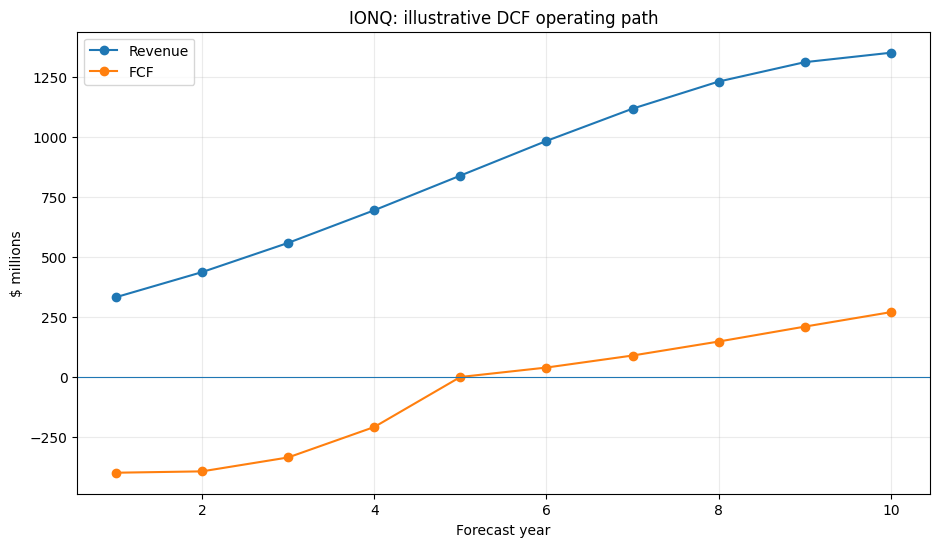

In [35]:
# Example: visualize one scenario. Change ticker as desired.
DCF_TICKER='IONQ' if 'IONQ' in dcf_schedules else next(iter(dcf_schedules),None)
if DCF_TICKER:
    sched=dcf_schedules[DCF_TICKER]
    display(sched)
    fig,ax=plt.subplots(figsize=(11,6))
    ax.plot(sched['Year'],sched['Revenue $000']/1000,marker='o',label='Revenue')
    ax.plot(sched['Year'],sched['FCF $000']/1000,marker='o',label='FCF')
    ax.axhline(0,linewidth=.8)
    ax.set_title(f'{DCF_TICKER}: illustrative DCF operating path')
    ax.set_xlabel('Forecast year'); ax.set_ylabel('$ millions')
    ax.legend(); ax.grid(alpha=.25); plt.show()

Years to positive FCF,2,3,4,5,6,7,8
WACC,,,,,,,
10.0%,10.2754,9.4709,8.5821,7.6137,6.5738,5.4745,4.3306
12.5%,8.4285,7.6637,6.8313,5.9380,4.9934,4.0098,3.0015
15.0%,7.4114,6.6827,5.9011,5.0747,4.2138,3.3303,2.4376
17.5%,6.7864,6.0907,5.3553,4.5888,3.8015,3.0051,2.2114
20.0%,6.3749,5.7096,5.0160,4.3032,3.5813,2.8608,2.1522
22.5%,6.0907,5.4534,4.7980,4.1336,3.4696,2.8156,2.1806
25.0%,5.8875,5.2761,4.6556,4.0349,3.4226,2.8271,2.2559


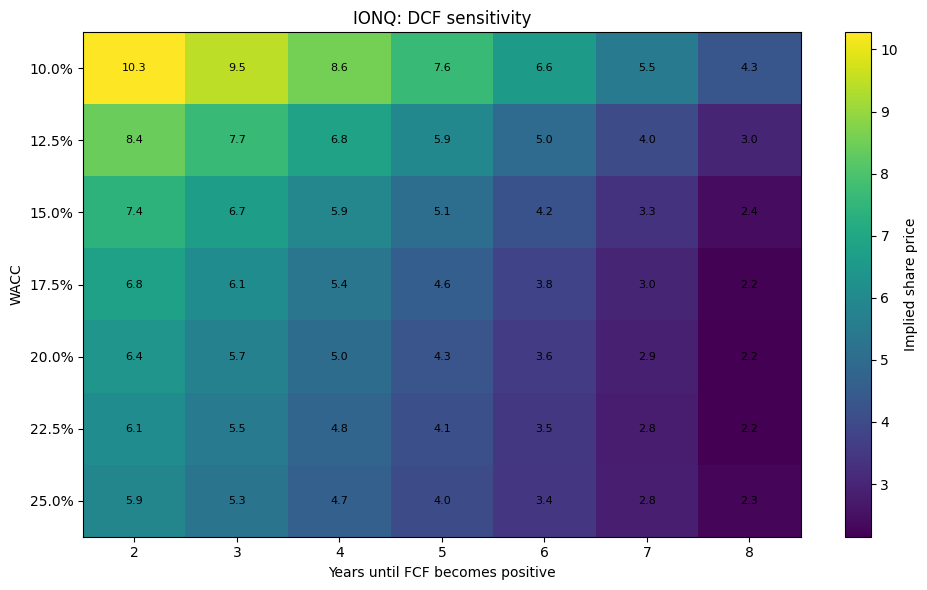

In [36]:
def dcf_sensitivity(ticker,wacc_grid=None,years_grid=None):
    if wacc_grid is None: wacc_grid=np.arange(.10,.251,.025)
    if years_grid is None: years_grid=range(2,9)
    r=dcf_inputs.loc[ticker]
    out=pd.DataFrame(index=[f'{w:.1%}' for w in wacc_grid],columns=list(years_grid),dtype=float)
    for w in wacc_grid:
        for y in years_grid:
            res=dcf_early_stage(r['Revenue0 $000'],r['FCF0 $000'],r['Net Cash $000'],r['Shares $000'],w,
                                years_to_positive_fcf=y,initial_revenue_growth=r['Initial revenue growth'],
                                target_fcf_margin=r['Target FCF margin'],terminal_growth=r['Terminal growth'])
            out.loc[f'{w:.1%}',y]=res[0]['Implied Price'] if res else np.nan
    out.index.name='WACC'; out.columns.name='Years to positive FCF'
    return out

if DCF_TICKER:
    sens=dcf_sensitivity(DCF_TICKER)
    display(sens)
    fig,ax=plt.subplots(figsize=(10,6))
    im=ax.imshow(sens.values,aspect='auto')
    ax.set_xticks(range(len(sens.columns))); ax.set_xticklabels(sens.columns)
    ax.set_yticks(range(len(sens.index))); ax.set_yticklabels(sens.index)
    for i in range(sens.shape[0]):
        for j in range(sens.shape[1]):
            if pd.notna(sens.iloc[i,j]): ax.text(j,i,f'{sens.iloc[i,j]:.1f}',ha='center',va='center',fontsize=8)
    fig.colorbar(im,ax=ax,label='Implied share price')
    ax.set_xlabel('Years until FCF becomes positive'); ax.set_ylabel('WACC')
    ax.set_title(f'{DCF_TICKER}: DCF sensitivity')
    plt.tight_layout(); plt.show()

### Why the DCF remains a scenario model

The quantum-focused firms require explicit commercialization assumptions because current negative FCF cannot simply be extrapolated. The incumbents begin from positive audited FCF but their DCF values the **whole corporation**, not the quantum program. Inspect `Terminal Value % of EV`: a very high percentage means the output is dominated by long-run assumptions. For startups, future dilution should also be modeled explicitly in a more advanced version.


## 15. Reverse DCF: what operating assumptions does the current price require?

In [37]:
def solve_target_fcf_margin(t,low=.01,high=.80,tol=1e-4,max_iter=80):
    row=dcf_inputs.loc[t]
    mkt=fin_snapshot.loc[t,'Price']
    if pd.isna(mkt) or pd.isna(row['Shares $000']) or row['Shares $000']<=0 or pd.isna(row['Revenue0 $000']) or row['Revenue0 $000']<=0:
        return np.nan
    def price_for(margin):
        res=dcf_early_stage(row['Revenue0 $000'],row['FCF0 $000'],row['Net Cash $000'],row['Shares $000'],row['WACC'],
                            years_to_positive_fcf=int(row['Years to positive FCF']),initial_revenue_growth=row['Initial revenue growth'],
                            target_fcf_margin=margin,terminal_growth=row['Terminal growth'])
        return res[0]['Implied Price'] if res else np.nan
    plo,phi=price_for(low),price_for(high)
    if pd.isna(plo) or pd.isna(phi) or not (min(plo,phi)<=mkt<=max(plo,phi)): return np.nan
    for _ in range(max_iter):
        mid=(low+high)/2; pm=price_for(mid)
        if abs(pm-mkt)<tol: return mid
        if pm<mkt: low=mid
        else: high=mid
    return (low+high)/2

reverse=[]
for t in TICKERS:
    if t in dcf_inputs.index:
        reverse.append({'Ticker':t,'Current Price':fin_snapshot.loc[t,'Price'],'Implied target FCF margin':solve_target_fcf_margin(t)})
reverse_dcf=pd.DataFrame(reverse).set_index('Ticker')
display(reverse_dcf)

,Current Price,Implied target FCF margin
Ticker,,
ARQQ,19.5200,NaN
IONQ,40.7050,NaN
QBTS,17.8250,NaN
QNC,1.7050,NaN
QUBT,8.5000,NaN
QUCY,1.3700,NaN
RGTI,16.1250,NaN
XNDU,7.6800,NaN
IBM,237.6600,0.1036


## 16. Filing-based qualitative context tools

In [38]:
try:
    from pypdf import PdfReader
except Exception: PdfReader=None
REPORT_FILE_MAP={'ARQQ':REPORT_DIR/'ARQQ_2025.pdf','IONQ':REPORT_DIR/'IONQ_2025.pdf','QBTS':REPORT_DIR/'QBTS_2025.pdf','QNC':REPORT_DIR/'QNC_2025_b.pdf','QUBT':REPORT_DIR/'QUBT_2025.pdf','QUCY':REPORT_DIR/'QUCY_2025.pdf','RGTI':REPORT_DIR/'RGTI_2025.pdf','XNDU':REPORT_DIR/'XNDU_2025.pdf','IBM':INCUMBENT_ROOT/'ibm-annual-report-2025.pdf','GOOG':INCUMBENT_ROOT/'GOOG-10-K-2025.pdf','MSFT':INCUMBENT_ROOT/'Microsoft_2025_AnnualReport.pdf'}
def filing_keyword_pages(ticker,keywords=('quantum','going concern','liquidity','commercialization','revenue','research and development','partnership'),max_hits=4):
    if PdfReader is None: return pd.DataFrame()
    path=Path(REPORT_FILE_MAP[ticker]); reader=PdfReader(str(path)); rows=[]; counts={k:0 for k in keywords}
    for i,p in enumerate(reader.pages):
        text=' '.join((p.extract_text() or '').split()); low=text.lower()
        for kw in keywords:
            if counts[kw]>=max_hits: continue
            loc=low.find(kw.lower())
            if loc>=0: rows.append({'Ticker':ticker,'Keyword':kw,'PDF page':i+1,'Context':text[max(0,loc-220):loc+520]}); counts[kw]+=1
    return pd.DataFrame(rows)
def show_filing_context(ticker,keyword='quantum',max_hits=5): display(filing_keyword_pages(ticker,[keyword],max_hits).head(max_hits))
# Example: show_filing_context('IBM','quantum',3)


### Qualitative context for the strategic incumbents

- **IBM:** the 2025 report says company-wide R&D exceeded **$8.3 billion**, explicitly includes quantum computing, and discusses a roadmap toward quantum advantage and fault tolerance.
- **Alphabet/Google:** the 2025 10-K describes long-term investment in frontier technologies **including quantum computing**, but quantum is not a standalone reporting segment.
- **Microsoft:** the 2025 report highlights **Majorana 1** and an operational Level 2 quantum computer developed with Atom Computing, alongside very large cloud/AI infrastructure and R&D investments.

These disclosures support using the three firms as strategic capital/technology benchmarks rather than direct startup valuation peers.

### Qualitative interpretation checklist

When reviewing the filing contexts, look for factors that can explain why conventional ratios differ dramatically across the peer set:

- **Technology modality and commercialization horizon:** trapped ion (IONQ), annealing (QBTS), superconducting gate-model systems (RGTI), integrated/photonic approaches (QUBT and XNDU), and quantum-security/entropy applications (ARQQ and QNC) can have very different capex, R&D, gross-margin, and revenue timing.
- **Customer concentration and government contracts:** small revenue bases can make one contract dominate annual growth.
- **Acquisitions and goodwill:** rapid inorganic expansion can inflate assets and make book-value comparisons difficult.
- **Stock compensation and equity issuance:** accounting losses may be partly non-cash, but dilution is economically real for shareholders.
- **Cash runway and financing dependence:** compare cash to annualized FCF burn and inspect going-concern/liquidity language.
- **Strategic discontinuities:** QUCY's predecessor historical data should not be interpreted as if they were homogeneous with the pure-play quantum-computing firms.

## 17. Compact comparative dashboard

In [39]:
dashboard=pd.DataFrame(index=TICKERS); dashboard['Peer group']=[PEER_GROUP[t] for t in TICKERS]
for c in ['Price','Market Cap $000','TTM Revenue $000','Revenue Growth approx','Gross Margin','Operating Margin','TTM Net Income $000','FCF $000 (TTM/latest FY)','FCF basis','Cash+ST Inv $000','Cash Runway Years (FCF burn)','Debt / Equity','Price / Sales','EV / Sales','R&D / Revenue']: dashboard[c]=fin_snapshot[c] if c in fin_snapshot else np.nan
for c in ['Geometric Avg Annualized','Annualized Std Dev','Skewness','Excess Kurtosis','Max Drawdown']: dashboard[c]=ret_stats[c] if c in ret_stats else np.nan
for c in ['CAPM beta','Adj R2','Residual Std Ann']: dashboard[c]=ff_table[c] if c in ff_table else np.nan
dashboard['Cost of Equity']=wacc_table['Cost of Equity']; dashboard['WACC']=wacc_table['WACC']; dashboard['Illustrative DCF Price']=dcf_values['Implied Price'] if len(dcf_values) else np.nan; display(dashboard)


,Peer group,Price,Market Cap $000,TTM Revenue $000,Revenue Growth approx,Gross Margin,Operating Margin,TTM Net Income $000,FCF $000 (TTM/latest FY),FCF basis,Cash+ST Inv $000,Cash Runway Years (FCF burn),Debt / Equity,Price / Sales,EV / Sales,R&D / Revenue,Geometric Avg Annualized,Annualized Std Dev,Skewness,Excess Kurtosis,Max Drawdown,CAPM beta,Adj R2,Residual Std Ann,Cost of Equity,WACC,Illustrative DCF Price
ARQQ,Quantum-focused,19.5200,"292,800.0000",624.0000,0.3448,NaN,-53.9744,"-33,032.0000","-21,536.0000",Vendor TTM,"36,978.0000",1.7170,0.0277,469.2308,411.1795,NaN,-0.3768,1.3558,1.1719,6.5853,-0.9960,1.6376,0.0827,1.3051,0.1219,0.1296,2.4261
IONQ,Quantum-focused,40.7050,"15,510,396.7821","246,474.0000",3.7064,0.3085,-4.0824,"-1,363,670.0000","-484,227.0000",Vendor TTM,"2,118,969.0000",4.3760,0.0000,62.9291,54.3320,1.8207,0.3181,1.0234,0.7756,4.2462,-0.9000,2.8010,0.3366,0.8382,0.1801,0.1801,4.5185
QBTS,Quantum-focused,17.8250,"6,631,096.4470","12,425.0000",-0.4422,0.6419,-13.7288,"-248,697.0000","-119,076.0000",Vendor TTM,"546,215.0000",4.5871,0.0323,533.6899,492.5484,6.5822,0.1928,1.4810,2.5606,21.9245,-0.9667,2.3379,0.1333,1.3946,0.1569,0.1564,1.3412
QNC,Quantum-focused,1.7050,"374,111.1000",16.7850,NaN,NaN,-626.4550,"-10,035.9690","-2,991.0000",Vendor TTM,"23,953.8390",8.0086,0.0042,"22,288.4182","20,868.0284",63.3220,-0.7577,0.8388,0.5728,0.4272,-0.5442,3.2750,0.3407,0.7247,0.2037,0.2037,0.1085
QUBT,Quantum-focused,8.5000,"1,916,699.0000","9,824.0000",36.3536,-0.1892,-7.7548,"-14,977.0000","-51,478.0000",Vendor TTM,"954,170.0000",18.5355,0.0000,195.1037,97.9773,2.7392,0.1684,1.4238,2.5936,19.1833,-0.9752,1.4914,0.0740,1.3813,0.1146,0.1146,4.2944
QUCY,Quantum-focused,1.3700,"34,152.7300",396.4300,-0.7475,1.2856,-61.9620,"-27,581.5500","-12,031.0000",Vendor TTM,"13,376.0400",1.1118,0.0083,86.1507,52.8350,9.7096,1.5392,4.8541,8.8256,86.8972,-0.7022,5.4299,0.0205,5.5317,0.3115,0.3103,0.4904
RGTI,Quantum-focused,16.1250,"5,380,541.6250","13,353.0000",0.6849,0.3461,-7.2762,"-238,672.0000","-87,582.0000",Vendor TTM,"393,709.0000",4.4953,0.0000,402.9463,373.4616,5.4709,0.1055,1.3625,1.2298,6.7345,-0.9602,2.5262,0.1809,1.2458,0.1663,0.1663,1.1284
XNDU,Quantum-focused,7.6800,"2,292,567.2755","4,617.0000",1.9056,0.9218,-15.0145,"-70,667.0000","-74,224.0000",FY2025 audited annual report,"16,164.0000",0.2178,1.2272,496.5491,499.5454,11.9638,-0.3902,2.0979,1.0444,11.0364,-0.7924,5.2474,0.0955,2.3076,0.3024,0.2993,-0.0847
IBM,Strategic incumbent,237.6600,"223,907,662.8959","69,097,000.0000",0.0790,0.5810,0.1839,"10,725,000.0000","11,455,000.0000",FY2025 audited annual report,"8,132,000.0000",NaN,1.8946,3.2405,4.0674,0.1267,0.1433,0.3144,-1.2490,23.5239,-0.3898,0.7464,0.3022,0.2627,0.0773,0.0651,383.3928
GOOG,Strategic incumbent,343.3250,"4,198,842,522.6123","445,866,000.0000",0.2005,0.6090,0.3311,"244,119,000.0000","73,266,000.0000",FY2025 audited annual report,"242,474,000.0000",NaN,0.1760,9.4173,9.1263,0.1547,0.2789,0.3228,0.0709,3.6220,-0.4460,1.0950,0.5678,0.2129,0.0947,0.0927,131.6899


## 18. Main analytical takeaways to investigate, not pre-impose

The purpose of this notebook is to make the central economic tradeoffs visible rather than mechanically rank the firms. Quantum-focused companies can have high valuations despite tiny current revenue because markets are pricing long commercialization runways and highly skewed outcomes. Cash balances reduce financing risk but must be compared with R&D intensity, burn, capex, and dilution.

IBM, Alphabet, and Microsoft are deliberately different benchmarks: consolidated profitability and financing capacity can support quantum R&D without the quantum program itself generating near-term standalone cash flow. Their company-wide multiples are therefore poor direct startup comparables, which is why the notebook separates the groups for standardized ratio profiles and valuation medians while retaining all firms in return/factor/network analysis.

Return-network centrality describes market co-movement, while the accounting network describes similarity in working-capital structure; neither establishes technological influence or actual supply-chain links. The JKP section now separates same-day importance from lagged predictability and makes the importance score auditable. The DCF/reverse-DCF section translates prices into explicit assumptions about commercialization timing, growth, margins, discount rates, terminal value, and dilution.


## 19. Optional exports

In [40]:
# Uncomment if you want workbook-style outputs from a local Jupyter session.
# with pd.ExcelWriter('quantum_financial_analysis_outputs.xlsx') as writer:
#     coverage.to_excel(writer,'Coverage')
#     ret_stats.to_excel(writer,'Return Stats')
#     corr.to_excel(writer,'Correlations')
#     ff_table.to_excel(writer,'FF5')
#     fin_snapshot.to_excel(writer,'Financial Ratios')
#     wacc_table.to_excel(writer,'WACC')
#     valuation_table.to_excel(writer,'Valuation')
#     peer_implied.to_excel(writer,'Peer Implied')
#     dcf_inputs.to_excel(writer,'DCF Inputs')
#     if len(dcf_values): dcf_values.to_excel(writer,'DCF Values')
#     reverse_dcf.to_excel(writer,'Reverse DCF')
#     dashboard.to_excel(writer,'Dashboard')
# print('Export cell is intentionally commented out so the notebook does not write files unless the user chooses to.')